# 3. Analysis data from Foot / HeartRate / GPX (location)
1. Read data and do basic analysis   

In [1]:
#basic
import os
import math
from pathlib import Path
from datetime import datetime # datetime
#analysis
import numpy as np
import pandas as pd

#Statistik
import scipy.stats as stats
from scipy.signal import find_peaks

#plot
import matplotlib.pyplot as plt
import seaborn as sns

1. Read data
We have 5 data files in `.csv` format:  
- One file corresponds to the date `2025/11/16`, surface type `Grass`, and subject `P06P`.  
- The other four files correspond to the date `2025/11/17`, surface types `Asphalt`, `Grass`, `Forest`, and `Sand`, and subject `S07`.

We will read these data files and load them into a single DataFrame.

In [2]:
# read data form
input_path = r"C:/Users/abolhassni/Desktop/TU Darmstadt/Term 2/bewegung/Bewegunganalysieren/Bewegung/data/processed/Data frame from foot heart GPX"
# name of File as csv
os.makedirs(input_path, exist_ok=True)
file_names = [f for f in os.listdir(input_path) if f.endswith(".csv")] #list directory

name_of_dataframe = []
for i in range(len(file_names)):
    name_df = file_names[i]
    name = file_names[i].replace(".csv","")
    name_of_dataframe.append(name)
    path = f"{input_path}/{name_df}"
    data = pd.read_csv(path)
    globals()[name] = data  #Erstellt automatisch ein DataFrame mit dem Dateinamen

C:\Users\abolhassni\AppData\Local\Temp\ipykernel_11584\208459259.py:13: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)
C:\Users\abolhassni\AppData\Local\Temp\ipykernel_11584\208459259.py:13: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)
C:\Users\abolhassni\AppData\Local\Temp\ipykernel_11584\208459259.py:13: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)
C:\Users\abolhassni\AppData\Local\Temp\ipykernel_11584\208459259.py:13: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)
C:\Users\abolhassni\AppData\Local\Temp\ipykernel_11584\208459259.py:13: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(p

In [3]:
name_of_dataframe

['Asphalt_S07_01_341_Date_2025_11_17_Time_10_09_36',
 'Forest_S07_02_492_Date_2025_11_17_Time_09_53_52',
 'Grass_P06P_01_845_Date_2025_11_16_Time_14_46_47',
 'Grass_S07_01_980_Date_2025_11_17_Time_09_27_24',
 'Sand__S07_01_073_Date_2025_11_17_Time_09_15_09']

# fillna
The DataFrames contain columns with `null` values due to timing mismatches:  
- Foot force data is sampled at **0.01-second** intervals.  
- Heart rate (`HR`) and location data (e.g., `longitude`, `latitude`, `elevation`) are sampled at **1-second** intervals.

To align the data, we fill the `null` values using the **`interpolate()`** method. This performs linear interpolation such that:
- If the first valid value is `109` and the next is `111`, the 99 intermediate values (corresponding to 0.01-second steps) are filled **in ascending order** from `109` to `111`.  
- Conversely, if values decrease (e.g., from `111` to `109`), the intermediate values are filled **in descending order**.

The interpolated columns include:  
`HR (bpm)`, `Speed (km/h)`, `Cadence`, `Distances (m)`, `longitude`, `latitude`, `elevation`.

In [4]:
output_path = r"C:/Users/abolhassni/Desktop/TU Darmstadt/Term 2/bewegung/Bewegunganalysieren/Bewegung/data/processed/Data frame from foot heart GPX fillna"
for i in name_of_dataframe:
    df = globals()[i].copy()
    df[df.columns[16:]] = df[df.columns[16:]].interpolate(method='polynomial', order=2)
    df['Speed (km/h)'] = df['Speed (km/h)'].abs() # keine negative Geschwindigkeit
    df['Cadence'] = df['Cadence'].abs()
    df['Distances (m)'] = df['Distances (m)'].abs()
    globals()[i] = df
    output_file = os.path.join(output_path, f"{i}.csv")
    globals()[i].to_csv(output_file, index=False) 



C:\Users\abolhassni\AppData\Local\Temp\ipykernel_11584\3218238613.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df[df.columns[16:]] = df[df.columns[16:]].interpolate(method='polynomial', order=2)
C:\Users\abolhassni\AppData\Local\Temp\ipykernel_11584\3218238613.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df[df.columns[16:]] = df[df.columns[16:]].interpolate(method='polynomial', order=2)
C:\Users\abolhassni\AppData\Local\Temp\ipykernel_11584\3218238613.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df[df.columns[16:]] = df[df.columns[16:]].interpolate(method='polynomial', order=2)
C:\Users\abolhas

In [5]:
input_path = r"C:/Users/abolhassni/Desktop/TU Darmstadt/Term 2/bewegung/Bewegunganalysieren/Bewegung/data/processed/Data frame from foot heart GPX fillna"
# name of File as csv
os.makedirs(input_path, exist_ok=True)
file_names = [f for f in os.listdir(input_path) if f.endswith(".csv")]

name_of_dataframe = []
for i in range(len(file_names)):
    name_df = file_names[i]
    name = file_names[i].replace(".csv","") 
    name_of_dataframe.append(name)
    path = f"{input_path}/{name_df}"
    data = pd.read_csv(path)
    globals()[name] = data

C:\Users\abolhassni\AppData\Local\Temp\ipykernel_11584\1633787472.py:12: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)
C:\Users\abolhassni\AppData\Local\Temp\ipykernel_11584\1633787472.py:12: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)
C:\Users\abolhassni\AppData\Local\Temp\ipykernel_11584\1633787472.py:12: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)
C:\Users\abolhassni\AppData\Local\Temp\ipykernel_11584\1633787472.py:12: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)
C:\Users\abolhassni\AppData\Local\Temp\ipykernel_11584\1633787472.py:12: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_

# Q1 :
The highest speed on 2025/11/17 on Asphalt, Forest, Grass, and Sand surfaces is what?   
Calculation method: What is the average of the top 1% of speeds?   Perzenteile
| Date       | Foundation | Speed (km/h) |
|------------|------------|---------------|
| 17-11-2025 | Asphalt    | 15.505        |
| 17-11-2025 | Forest     | 16.462        |
| 17-11-2025 | Grass      | 11.817        |
| 17-11-2025 | Sand       | 14.337        |

Calculation method: What is the average of the top 10% of speeds?   Dezile 
| Date       | Foundation | Speed (km/h) |
|------------|------------|---------------|
| 17-11-2025 | Asphalt    | 14.829        |
| 17-11-2025 | Forest     | 14.672        |
| 17-11-2025 | Grass      | 10.846        |
| 17-11-2025 | Sand       | 13.654        |

In [6]:
name_of_dataframe

['Asphalt_S07_01_341_Date_2025_11_17_Time_10_09_36',
 'Forest_S07_02_492_Date_2025_11_17_Time_09_53_52',
 'Grass_P06P_01_845_Date_2025_11_16_Time_14_46_47',
 'Grass_S07_01_980_Date_2025_11_17_Time_09_27_24',
 'Sand__S07_01_073_Date_2025_11_17_Time_09_15_09']

In [7]:
Asphalt_S07_01_341_Date_2025_11_17_Time_10_09_36.head()

,type name,value,foundation,Date,Start_Time,Time_Running,Time_x,L_Heel,L_Midfoot,L_Forefoot,...,Pace (min/km),Cadence,Altitude (m),Stride length (m),Distances (m),Temperatures (C),Power (W),latitude,longitude,elevation
0,Name,Maximilian Stasica,Asphalt,2025-11-17,10:09:36,10:09:36.00,0.00,160.65,0.0,630.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Sport,RUNNING,Asphalt,2025-11-17,10:09:36,10:09:36.01,0.01,148.05,0.0,642.60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Date,17-11-2025,Asphalt,2025-11-17,10:09:36,10:09:36.02,0.02,129.15,0.0,661.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Start time,11:10:27,Asphalt,2025-11-17,10:09:36,10:09:36.03,0.03,113.40,0.0,677.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Duration,00:06:55,Asphalt,2025-11-17,10:09:36,10:09:36.04,0.04,94.50,0.0,686.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
name_17 =  [name_of_dataframe[i] for i in [0, 1, 3, 4]]
for i in name_17:
    df = globals()[i].copy()
    sorted_speeds = df["Speed (km/h)"].sort_values(ascending=False)
    top_10_percent = sorted_speeds.head(int(len(sorted_speeds) * 0.10)) #Das Maximum ist unzuverlässig
    mean_top_10_percent = top_10_percent.mean()
    print(f"Date: {df["value"].iloc[2]}  foundation: {df["foundation"].iloc[0]}  speed(km/h): {mean_top_10_percent}")



Date: 17-11-2025  foundation: Asphalt  speed(km/h): 14.829613449274571
Date: 17-11-2025  foundation: Forest  speed(km/h): 14.672986153101078
Date: 17-11-2025  foundation: Grass  speed(km/h): 10.846453299447822
Date: 17-11-2025  foundation: Sand  speed(km/h): 13.65484414761767


In [9]:
for i in name_17:
    df = globals()[i].copy()
    sorted_speeds = df["Speed (km/h)"].sort_values(ascending=True) 
    bottom_10_percent = sorted_speeds.head(int(len(sorted_speeds) * 0.10))  
    mean_bottom_10_percent = bottom_10_percent.mean() 
    print(f"Date: {df['value'].iloc[2]}  foundation: {df['foundation'].iloc[0]}  speed(km/h): {mean_bottom_10_percent}")


Date: 17-11-2025  foundation: Asphalt  speed(km/h): 0.04453417680379232
Date: 17-11-2025  foundation: Forest  speed(km/h): 0.09138707179433929
Date: 17-11-2025  foundation: Grass  speed(km/h): 1.0648104296894412
Date: 17-11-2025  foundation: Sand  speed(km/h): 0.08555169332226016


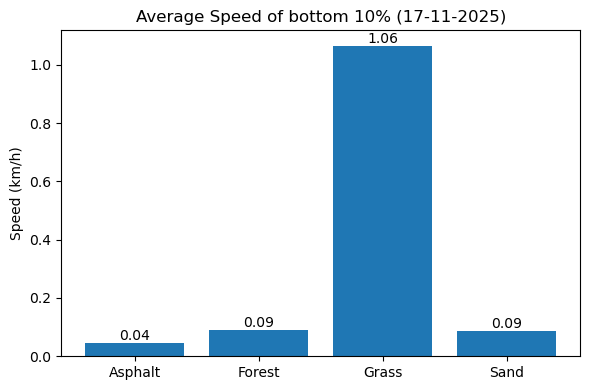

In [10]:
foundations = ["Asphalt", "Forest", "Grass", "Sand"]
speed = [0.04453417680379232, 0.09138707179433929, 1.0648104296894412, 0.08555169332226016]

plt.figure(figsize=(6,4))
bars = plt.bar(foundations, speed)

plt.ylabel("Speed (km/h)")
plt.title("Average Speed of bottom 10% (17-11-2025)")

plt.bar_label(bars, fmt="%.2f") #zwei Nachkommastellen

plt.tight_layout() #Texte sich nicht überlappen
plt.show()


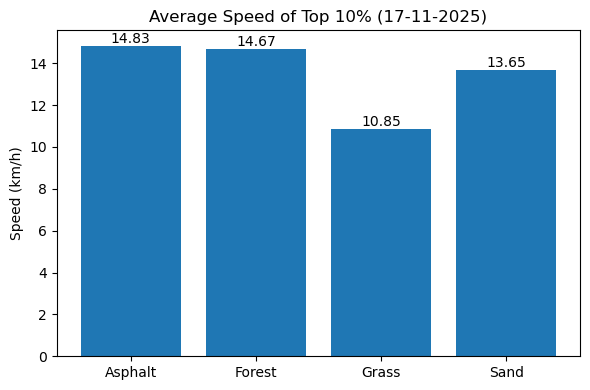

In [11]:
foundations = ["Asphalt", "Forest", "Grass", "Sand"]
speed = [14.829, 14.672, 10.846, 13.654]

plt.figure(figsize=(6,4))
bars = plt.bar(foundations, speed)

plt.ylabel("Speed (km/h)")
plt.title("Average Speed of Top 10% (17-11-2025)")

plt.bar_label(bars, fmt="%.2f")

plt.tight_layout()
plt.show()


Date: 17-11-2025  foundation: Asphalt  speed(km/h): 14.829613449274571
Date: 17-11-2025  foundation: Forest  speed(km/h): 14.672986153101078
Date: 17-11-2025  foundation: Grass  speed(km/h): 10.846453299447822
Date: 17-11-2025  foundation: Sand  speed(km/h): 13.65484414761767


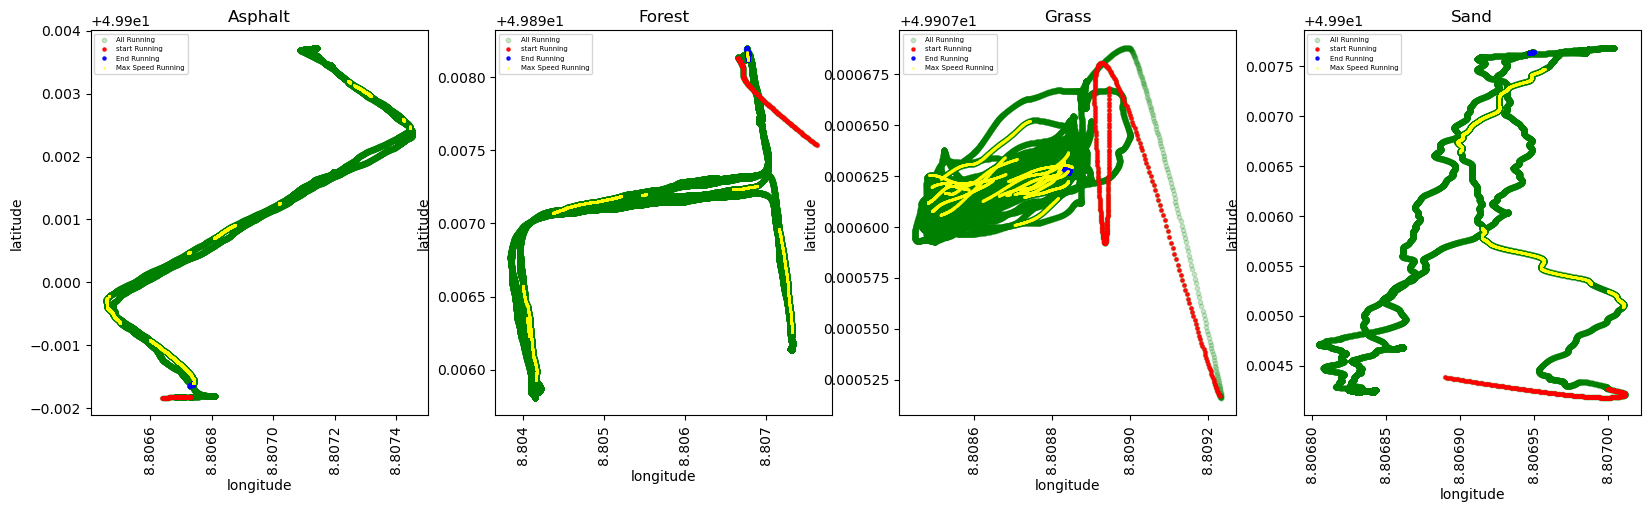

In [12]:
name_17 =  [name_of_dataframe[i] for i in [0, 1, 3, 4]]
loc_plot = 1
plt.figure(figsize=(20,5))
for i in name_17:
    df = globals()[i].copy()
    df_first = df.dropna(subset=["latitude", "longitude"]).head(300).copy()
    df_end = df.dropna(subset=["latitude", "longitude"]).tail(300).copy()
    plt.subplot(1,4,loc_plot)
    plt.scatter(df["longitude"], df["latitude"],
            s=10, color="green", alpha=0.2, linestyle='-',
            label="All Running")
    plt.scatter(df_first["longitude"], df_first["latitude"],
            s=5, color="red", alpha=0.9, linestyle='-',
            label="start Running")
    plt.scatter(df_end["longitude"], df_end["latitude"],
            s=5, color="blue", alpha=0.9, linestyle='-',
            label="End Running")
    top = 0.10
    sorted_df_speed = df.sort_values(by="Speed (km/h)", ascending=False)
    top_df = sorted_df_speed.head(int(len(sorted_df_speed) * top))
    plt.scatter(top_df["longitude"], top_df["latitude"],
            s=1, color="yellow", alpha=0.5, linestyle='-',
            label="Max Speed Running")
    mead_speed = top_df["Speed (km/h)"].mean()
    print(f"Date: {df["value"].iloc[2]}  foundation: {df["foundation"].iloc[0]}  speed(km/h): {mead_speed}")
    loc_plot+=1
    plt.xlabel("longitude")
    plt.xticks(rotation=90)
    plt.ylabel("latitude")
    plt.title(f"{df["foundation"].iloc[0]}")
    plt.legend(loc='upper left', fontsize=5)


# df = globals()[name_17[0]].copy()
# df_first = df.dropna(subset=["latitude", "longitude"]).head(1000).copy()
# df_end = df.dropna(subset=["latitude", "longitude"]).tail(1000).copy()

# plt.figure(figsize=(20,10))
# plt.subplot(2,2,1)
# plt.scatter(df["longitude"], df["latitude"],
#             s=10, color="green", alpha=0.2, linestyle='-')

# plt.scatter(df_first["longitude"], df_first["latitude"],
#             s=5, color="red", alpha=0.9, linestyle='-')

# plt.scatter(df_end["longitude"], df_end["latitude"],
#             s=5, color="blue", alpha=0.9, linestyle='-')

# top = 0.10
# sorted_df_speed = df.sort_values(by="Speed (km/h)", ascending=False)
# top_df = sorted_speeds.head(int(len(sorted_speeds) * top))

# plt.scatter(top_df["longitude"], top_df["latitude"],
#             s=1, color="yellow", alpha=0.05, linestyle='-')



In [13]:
df.head()

,type name,value,foundation,Date,Start_Time,Time_Running,Time_x,L_Heel,L_Midfoot,L_Forefoot,...,Pace (min/km),Cadence,Altitude (m),Stride length (m),Distances (m),Temperatures (C),Power (W),latitude,longitude,elevation
0,Name,Maximilian Stasica,Sand,2025-11-17,09:15:09,09:15:09.00,0.00,221.56,0.0,286.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Sport,RUNNING,Sand,2025-11-17,09:15:09,09:15:09.01,0.01,219.24,0.0,286.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Date,17-11-2025,Sand,2025-11-17,09:15:09,09:15:09.02,0.02,216.92,0.0,286.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Start time,10:15:10,Sand,2025-11-17,09:15:09,09:15:09.03,0.03,216.92,0.0,290.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Duration,00:07:25,Sand,2025-11-17,09:15:09,09:15:09.04,0.04,214.60,0.0,286.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Date: 17-11-2025  foundation: Asphalt  speed(km/h): 14.829613449274571
Date: 17-11-2025  foundation: Forest  speed(km/h): 14.672986153101078
Date: 17-11-2025  foundation: Grass  speed(km/h): 10.846453299447822
Date: 17-11-2025  foundation: Sand  speed(km/h): 13.65484414761767


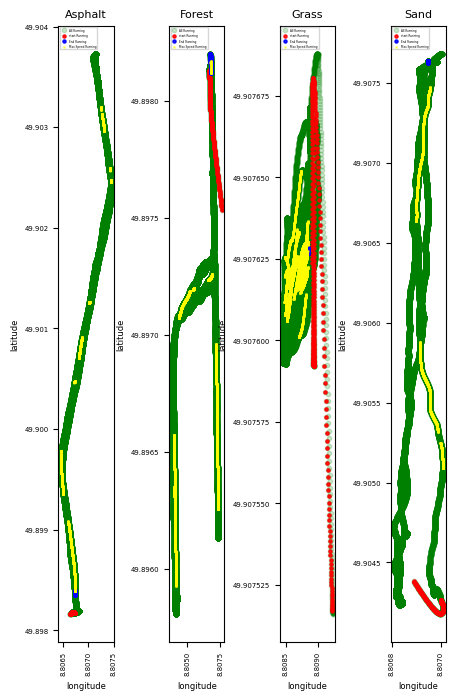

In [14]:
name_17 =  [name_of_dataframe[i] for i in [0, 1, 3, 4]]
loc_plot = 1
plt.figure(figsize=(5,8))
plt.subplots_adjust(wspace=1.0)
for i in name_17:
    df = globals()[i].copy()
    df_first = df.dropna(subset=["latitude", "longitude"]).head(300).copy()
    df_end = df.dropna(subset=["latitude", "longitude"]).tail(300).copy()
    plt.subplot(1,4,loc_plot)
    plt.scatter(df["longitude"], df["latitude"],
            s=10, color="green", alpha=0.2, linestyle='-',
            label="All Running")
    plt.scatter(df_first["longitude"], df_first["latitude"],
            s=5, color="red", alpha=0.9, linestyle='-',
            label="start Running")
    plt.scatter(df_end["longitude"], df_end["latitude"],
            s=5, color="blue", alpha=0.9, linestyle='-',
            label="End Running")
    top = 0.10
    sorted_df_speed = df.sort_values(by="Speed (km/h)", ascending=False)
    top_df = sorted_df_speed.head(int(len(sorted_df_speed) * top))
    plt.scatter(top_df["longitude"], top_df["latitude"],
            s=1, color="yellow", alpha=0.5, linestyle='-',
            label="Max Speed Running")
    mead_speed = top_df["Speed (km/h)"].mean()
    print(f"Date: {df["value"].iloc[2]}  foundation: {df["foundation"].iloc[0]}  speed(km/h): {mead_speed}")
    loc_plot+=1
    plt.xlabel("longitude", fontsize=6)
    plt.xticks(rotation=90, fontsize=5)
    plt.ylabel("latitude", fontsize=6)
    plt.yticks(fontsize=5)
    ax = plt.gca()
    ax.ticklabel_format(useOffset=False, style='plain') #keine wissenschaftliche Schreibweise
    plt.title(f"{df["foundation"].iloc[0]}", fontsize=8)
    plt.legend(loc='upper left', fontsize=2)

# Q2:
What is the highest heart rate (HR) on **2025/11/17** on the surfaces **Asphalt, Forest, Grass**, and **Sand**?  
**Calculation method**: the average of the top **1%** of HR values.   
The column `HR (bpm)` in your dataset stands for **Heart Rate**, measured in **beats per minute (bpm)**. This variable indicates how many times the person's heart beats per minute.   
HR stands for Heart Rate.  
bpm stands for beats per minute, meaning the number of heartbeats per minute.  
This value directly reflects the individual's cardiovascular activity during various tasks (in this case: walking or moving on different surfaces).
| HR (bpm) | General Interpretation |
|----------|------------------------|
| < 60     | Bradycardia (slow heart rate). May be normal in athletes, but can indicate a cardiac issue in other individuals. |
| 60 – 100 | Normal resting range for healthy adults. |
| 100 – 140| Light to moderate activity (e.g., brisk walking or stair climbing). |
| 140 – 180+| Intense exercise (e.g., running or vigorous activity). Varies depending on age and physical fitness level. |
| > 200    | Typically occurs in young individuals during maximal exertion; may indicate tachycardia in certain contexts. |

auf Deutsch 

| HR (bpm)  | Allgemeine Interpretation                                      |
|------------|---------------------------------------------------------------|
| < 60       | Bradykardie (langsamer Herzschlag). Kann bei Sportlern normal sein, aber auf ein kardiales Problem bei anderen Personen hinweisen. |
| 60 - 100   | Normaler Ruhebereich für gesunde Erwachsene.                  |
| 100 - 140  | Leichte bis mäßige Aktivität (z. B. zügiges Gehen oder Treppensteigen). |
| 140 - 180+ | Intensive Übung (z. B. Laufen oder kräftige Aktivität). Variiert je nach Alter und Fitnessniveau. |
| > 200      | Tritt typischerweise bei jungen Menschen während maximaler Anstrengung auf; kann auf Tachykardie in bestimmten Kontexten hinweisen. |


### Result 1%

| Date       | Foundation | HR (bpm) |
|------------|------------|----------|
| 17-11-2025 | Asphalt    | 175.05   |
| 17-11-2025 | Forest     | 180.05   |
| 17-11-2025 | Grass      | 159.35   |
| 17-11-2025 | Sand       | 164.90   |

### Result 10%
| Date       | Foundation | HR (bpm) |
|------------|------------|----------|
| 17-11-2025 | Asphalt    | 174.43   |
| 17-11-2025 | Forest     | 176.37   |
| 17-11-2025 | Grass      | 157.88   |
| 17-11-2025 | Sand       | 160.69   |

In [15]:
name_17 =  [name_of_dataframe[i] for i in [0, 1, 3, 4]]
for i in name_17:
    df = globals()[i].copy()
    sorted_speeds = df["HR (bpm)"].sort_values(ascending=False)
    top_1_percent = sorted_speeds.head(int(len(sorted_speeds) * 0.10))
    mean_top_1_percent = top_1_percent.mean()
    print(f"Date: {df["value"].iloc[2]}  foundation: {df["foundation"].iloc[0]}  HR (bpm): {mean_top_1_percent}")



Date: 17-11-2025  foundation: Asphalt  HR (bpm): 174.42743442650806
Date: 17-11-2025  foundation: Forest  HR (bpm): 176.3724545860722
Date: 17-11-2025  foundation: Grass  HR (bpm): 157.88075912954565
Date: 17-11-2025  foundation: Sand  HR (bpm): 160.68760675587004


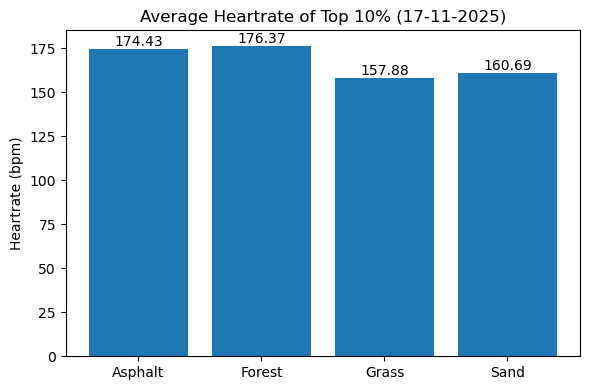

In [16]:
foundations = ["Asphalt", "Forest", "Grass", "Sand"]
heartrate = [174.42743442650806, 176.3724545860722, 157.88075912954565, 160.68760675587004]

plt.figure(figsize=(6,4))
bars = plt.bar(foundations, heartrate)

plt.ylabel("Heartrate (bpm)")
plt.title("Average Heartrate of Top 10% (17-11-2025)")

plt.bar_label(bars, fmt="%.2f")

plt.tight_layout()
plt.show()


Date: 17-11-2025  foundation: Asphalt  HR (bpm) : 174.42743442650806
Date: 17-11-2025  foundation: Forest  HR (bpm) : 176.3724545860722
Date: 17-11-2025  foundation: Grass  HR (bpm) : 157.88075912954565
Date: 17-11-2025  foundation: Sand  HR (bpm) : 160.68760675587004


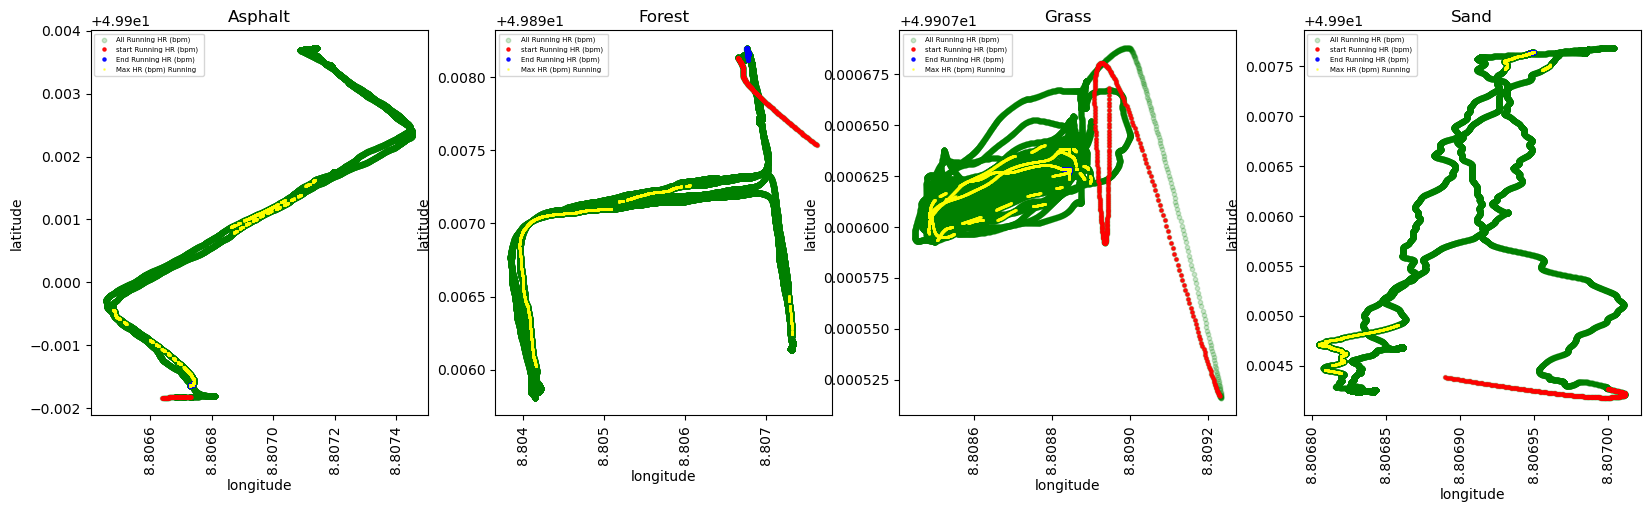

In [17]:

name_17 =  [name_of_dataframe[i] for i in [0, 1, 3, 4]]
loc_plot = 1
plt.figure(figsize=(20,5))
for i in name_17:
    df = globals()[i].copy()
    df_first = df.dropna(subset=["latitude", "longitude"]).head(300).copy()
    df_end = df.dropna(subset=["latitude", "longitude"]).tail(300).copy()
    plt.subplot(1,4,loc_plot)
    plt.scatter(df["longitude"], df["latitude"],
            s=10, color="green", alpha=0.2, linestyle='-',
            label="All Running HR (bpm)")
    
    plt.scatter(df_first["longitude"], df_first["latitude"],
            s=5, color="red", alpha=0.9, linestyle='-',
            label="start Running HR (bpm) ")
    
    plt.scatter(df_end["longitude"], df_end["latitude"],
            s=5, color="blue", alpha=0.9, linestyle='-',
            label="End Running HR (bpm)")
    top = 0.10
    sorted_df_speed = df.sort_values(by="HR (bpm)", ascending=False)
    top_df = sorted_df_speed.head(int(len(sorted_df_speed) * top))
    plt.scatter(top_df["longitude"], top_df["latitude"],
            s=1, color="yellow", alpha=0.5, linestyle='-',
            label="Max HR (bpm) Running")
    mead_HR = top_df["HR (bpm)"].mean()
    print(f"Date: {df["value"].iloc[2]}  foundation: {df["foundation"].iloc[0]}  HR (bpm) : {mead_HR}")
    loc_plot+=1
    plt.xlabel("longitude")
    plt.xticks(rotation=90)
    plt.ylabel("latitude")
    plt.title(f"{df["foundation"].iloc[0]}")
    plt.legend(loc='upper left', fontsize=5)


Date: 17-11-2025  foundation: Asphalt  speed(km/h): 14.829613449274571
Date: 17-11-2025  foundation: Forest  speed(km/h): 14.672986153101078
Date: 17-11-2025  foundation: Grass  speed(km/h): 10.846453299447822
Date: 17-11-2025  foundation: Sand  speed(km/h): 13.65484414761767


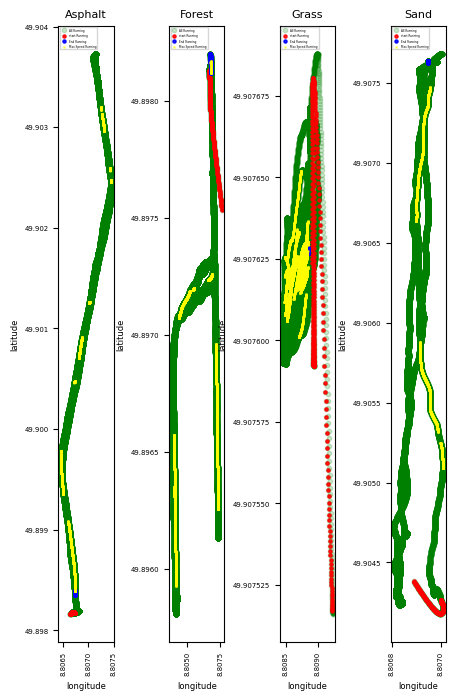

In [18]:

name_17 =  [name_of_dataframe[i] for i in [0, 1, 3, 4]]
loc_plot = 1
plt.figure(figsize=(5,8))
plt.subplots_adjust(wspace=1.0)
for i in name_17:
    df = globals()[i].copy()
    df_first = df.dropna(subset=["latitude", "longitude"]).head(300).copy()
    df_end = df.dropna(subset=["latitude", "longitude"]).tail(300).copy()
    plt.subplot(1,4,loc_plot)
    plt.scatter(df["longitude"], df["latitude"],
            s=10, color="green", alpha=0.2, linestyle='-',
            label="All Running")
    plt.scatter(df_first["longitude"], df_first["latitude"],
            s=5, color="red", alpha=0.9, linestyle='-',
            label="start Running")
    plt.scatter(df_end["longitude"], df_end["latitude"],
            s=5, color="blue", alpha=0.9, linestyle='-',
            label="End Running")
    top = 0.10
    sorted_df_speed = df.sort_values(by="Speed (km/h)", ascending=False)
    top_df = sorted_df_speed.head(int(len(sorted_df_speed) * top))
    plt.scatter(top_df["longitude"], top_df["latitude"],
            s=1, color="yellow", alpha=0.5, linestyle='-',
            label="Max Speed Running")
    mead_speed = top_df["Speed (km/h)"].mean()
    print(f"Date: {df["value"].iloc[2]}  foundation: {df["foundation"].iloc[0]}  speed(km/h): {mead_speed}")
    loc_plot+=1
    plt.xlabel("longitude", fontsize=6)
    plt.xticks(rotation=90, fontsize=5)
    plt.ylabel("latitude", fontsize=6)
    plt.yticks(fontsize=5)
    ax = plt.gca()
    ax.ticklabel_format(useOffset=False, style='plain')
    plt.title(f"{df["foundation"].iloc[0]}", fontsize=8)
    plt.legend(loc='upper left', fontsize=2)


# Q3:
What is the highest **Force** value on **2025/11/17** on the surfaces **Asphalt, Forest, Grass**, and **Sand**?  
**Calculation method**: the average of the top **1%** of Force values.   
There are three types of force:  **Heel**, **Midfoot**, and **Forefoot**.  

Forefoot (front of the foot), Midfoot (middle of the foot), and Heel (rear of the foot or heel) forces are commonly measured in biomechanical studies of walking or running using **force plates** or **instrumented insole sensors**. These forces indicate how much load (e.g., in newtons or as a percentage of body weight) is applied to each region of the foot at any given moment.  

| Region     | Location on Foot                          | Primary Function                |
|------------|-------------------------------------------|---------------------------------|
| Heel       | Back of the foot — first contact point in normal walking | Shock absorption               |
| Midfoot    | Midfoot — includes navicular and cuneiform bones | Force transmission and stabilization |
| Forefoot   | Front of the foot — includes metatarsal heads and toes | Propulsion (pushing the body forward) |

Auf Deutsch



| Region     | Lage am Fuß                             | Hauptfunktion                        |
|------------|-----------------------------------------|--------------------------------------|
| Ferse      | Hinterer Teil des Fußes – erster Kontaktpunkt beim normalen Gehen | Stoßdämpfung                        |
| Mittelfuß  | Mittelfuß – umfasst das Naviculare und die Keilbeine | Kraftübertragung und Stabilisierung |
| Vorfuß     | Vorderer Teil des Fußes – umfasst die Metatarsalköpfe und die Zehen | Vortrieb (das Vorwärtsdrücken des Körpers) |


In this dataset, **Midfoot** force is not recorded and has a value of zero.   
### for 1%

| Surface  | L_Heel   | L_Midfoot | L_Forefoot | Total_L_Foot | R_Forefoot | R_Midfoot | R_Heel   | Total_R_Foot |
|----------|----------|-----------|------------|--------------|------------|-----------|----------|--------------|
| Asphalt  | 1259.07  | 0.0       | 1636.98    | 1847.17      | 1626.25    | 0.0       | 990.05   | 1738.68      |
| Forest   | 1142.39  | 0.0       | 1620.26    | 1813.60      | 1601.97    | 0.0       | 964.30   | 1721.96      |
| Grass    | 1005.66  | 0.0       | 1570.68    | 1769.64      | 1553.32    | 0.0       | 899.12   | 1728.05      |
| Sand     | 1172.09  | 0.0       | 1649.28    | 1834.55      | 1659.79    | 0.0       | 1044.93  | 1779.86      |

### for 10%
| Surface  | L_Heel  | L_Midfoot | L_Forefoot | Total_L_Foot | R_Forefoot | R_Midfoot | R_Heel  | Total_R_Foot |
|----------|---------|-----------|------------|--------------|------------|-----------|---------|--------------|
| Asphalt  | 704.81  | 0.0       | 1389.81    | 1652.65      | 1395.01    | 0.0       | 594.89  | 1565.96      |
| Forest   | 677.09  | 0.0       | 1411.97    | 1643.26      | 1407.82    | 0.0       | 586.60  | 1568.36      |
| Grass    | 607.39  | 0.0       | 1260.47    | 1526.02      | 1239.75    | 0.0       | 554.75  | 1466.41      |
| Sand     | 702.75  | 0.0       | 1381.88    | 1628.80      | 1399.88    | 0.0       | 646.10  | 1586.98      |

In [19]:
name_17 = [name_of_dataframe[i] for i in [0, 1, 3, 4]]
df_col = globals()[name_17[0]].copy()
col = df_col.columns[7:15].copy()
print(col)
for i in name_17:
    df = globals()[i].copy()
    row_data = []
    for j in col:
        sorted_speeds = df[j].sort_values(ascending=False)
        top_1_percent = sorted_speeds.head(int(len(sorted_speeds) * 0.10))
        mean_top_1_percent = top_1_percent.mean()
        row_data.append(mean_top_1_percent)
    print({df["foundation"].iloc[0]} , list(row_data))



Index(['L_Heel', 'L_Midfoot', 'L_Forefoot', 'Total_L_Foot', 'R_Forefoot',
       'R_Midfoot', 'R_Heel', 'Total_R_Foot'],
      dtype='object')
{'Asphalt'} [np.float64(704.8118298144593), np.float64(0.0), np.float64(1389.8119385796545), np.float64(1652.6525463851565), np.float64(1395.013727873747), np.float64(0.0), np.float64(594.8920132224355), np.float64(1565.958310940499)]
{'Forest'} [np.float64(677.0850374664217), np.float64(0.0), np.float64(1411.9690993920542), np.float64(1643.2636010179558), np.float64(1407.820521702248), np.float64(0.0), np.float64(586.59766718507), np.float64(1568.3623017107307)]
{'Grass'} [np.float64(607.3874712300104), np.float64(0.0), np.float64(1260.472135704678), np.float64(1526.0191197130473), np.float64(1239.7524346136604), np.float64(0.0), np.float64(554.7510521596174), np.float64(1466.4078104917053)]
{'Sand'} [np.float64(702.7491004230684), np.float64(0.0), np.float64(1381.884259630372), np.float64(1628.7974081496327), np.float64(1399.8758383433535), np

In [20]:
df_col.columns

Index(['type name', 'value', 'foundation', 'Date', 'Start_Time',
       'Time_Running', 'Time_x', 'L_Heel', 'L_Midfoot', 'L_Forefoot',
       'Total_L_Foot', 'R_Forefoot', 'R_Midfoot', 'R_Heel', 'Total_R_Foot',
       'Time_y', 'HR (bpm)', 'Speed (km/h)', 'Pace (min/km)', 'Cadence',
       'Altitude (m)', 'Stride length (m)', 'Distances (m)',
       'Temperatures (C)', 'Power (W)', 'latitude', 'longitude', 'elevation'],
      dtype='object')

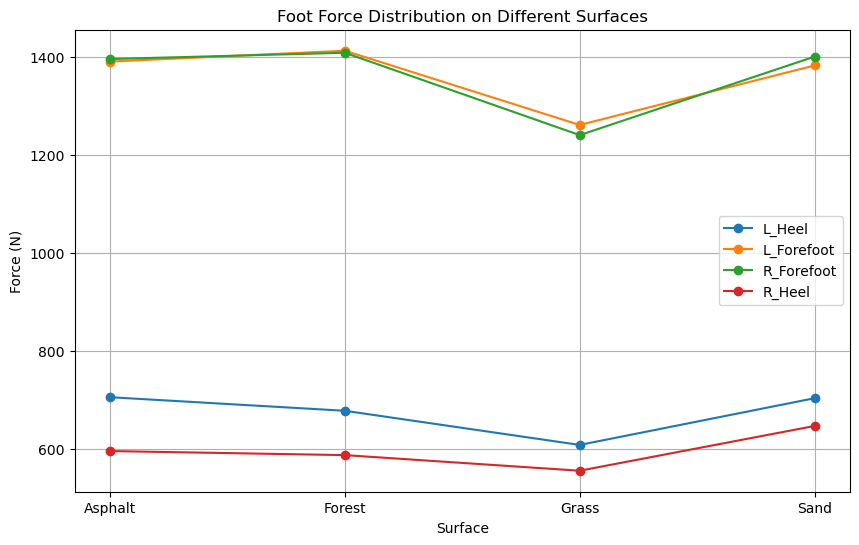

In [21]:

data = {
    "Surface": ["Asphalt", "Forest", "Grass", "Sand"],
    "L_Heel": [704.81, 677.09, 607.39, 702.75],
    "L_Forefoot": [1389.81, 1411.97, 1260.47, 1381.88],
    "R_Forefoot": [1395.01, 1407.82, 1239.75, 1399.88],
    "R_Heel": [594.89, 586.60, 554.75, 646.10],

}

df = pd.DataFrame(data)

plt.figure(figsize=(10, 6))


plt.plot(df["Surface"], df["L_Heel"], label="L_Heel", marker='o')
plt.plot(df["Surface"], df["L_Forefoot"], label="L_Forefoot", marker='o')
plt.plot(df["Surface"], df["R_Forefoot"], label="R_Forefoot", marker='o')
plt.plot(df["Surface"], df["R_Heel"], label="R_Heel", marker='o')


plt.title("Foot Force Distribution on Different Surfaces")
plt.xlabel("Surface")
plt.ylabel("Force (N)")
plt.legend()
plt.grid(True)


plt.show()


Index(['L_Heel', 'L_Midfoot', 'L_Forefoot', 'Total_L_Foot', 'R_Forefoot',
       'R_Midfoot', 'R_Heel', 'Total_R_Foot'],
      dtype='object')
{'Asphalt'} [np.float64(704.8118298144593), np.float64(0.0), np.float64(1389.8119385796545), np.float64(1652.6525463851565), np.float64(1395.013727873747), np.float64(0.0), np.float64(594.8920132224355), np.float64(1565.958310940499)]
{'Forest'} [np.float64(677.0850374664217), np.float64(0.0), np.float64(1411.9690993920542), np.float64(1643.2636010179558), np.float64(1407.820521702248), np.float64(0.0), np.float64(586.59766718507), np.float64(1568.3623017107307)]
{'Grass'} [np.float64(607.3874712300104), np.float64(0.0), np.float64(1260.472135704678), np.float64(1526.0191197130473), np.float64(1239.7524346136604), np.float64(0.0), np.float64(554.7510521596174), np.float64(1466.4078104917053)]
{'Sand'} [np.float64(702.7491004230684), np.float64(0.0), np.float64(1381.884259630372), np.float64(1628.7974081496327), np.float64(1399.8758383433535), np

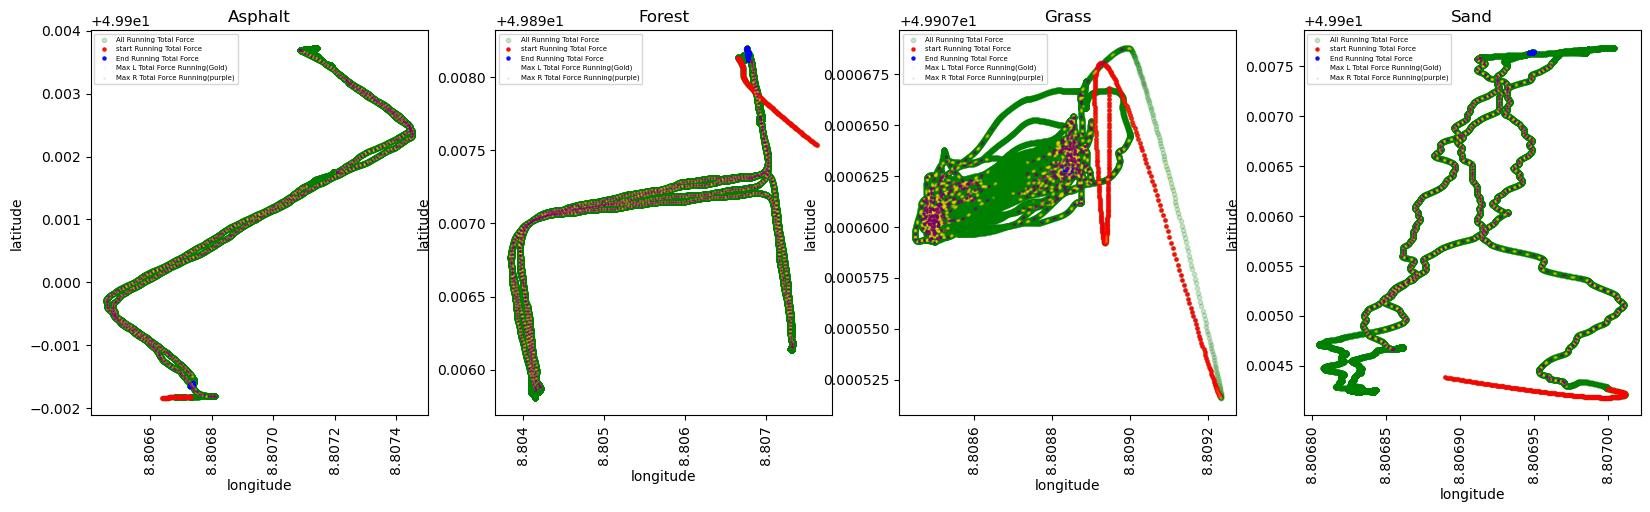

In [22]:

name_17 = [name_of_dataframe[i] for i in [0, 1, 3, 4]]
df_col = globals()[name_17[0]].copy()
col = df_col.columns[7:15].copy()
print(col)

loc_plot = 1
plt.figure(figsize=(20,5))
for i in name_17:
    df = globals()[i].copy()
    df_first = df.dropna(subset=["latitude", "longitude"]).head(300).copy()
    df_end = df.dropna(subset=["latitude", "longitude"]).tail(300).copy()
    plt.subplot(1,4,loc_plot)
    plt.scatter(df["longitude"], df["latitude"],
            s=10, color="green", alpha=0.2, linestyle='-',
            label="All Running Total Force")
    
    plt.scatter(df_first["longitude"], df_first["latitude"],
            s=5, color="red", alpha=0.9, linestyle='-',
            label="start Running Total Force")
    
    plt.scatter(df_end["longitude"], df_end["latitude"],
            s=5, color="blue", alpha=0.9, linestyle='-',
            label="End Running Total Force")   
    row_data = []
    for j in col:
        top = 0.10
        sorted_speeds = df[j].sort_values(ascending=False)
        top_1_percent = sorted_speeds.head(int(len(sorted_speeds) * top))
        mean_top_1_percent = top_1_percent.mean()
        row_data.append(mean_top_1_percent)
    print({df["foundation"].iloc[0]} , list(row_data))

    sorted_df_speed = df.sort_values(by="Total_L_Foot", ascending=False)
    top_df = sorted_df_speed.head(int(len(sorted_df_speed) * top))
    plt.scatter(top_df["longitude"], top_df["latitude"],
                s=1, color="gold", alpha=0.10, linestyle='-',
                label="Max L Total Force Running(Gold)")
    
    sorted_df_speed = df.sort_values(by="Total_R_Foot", ascending=False)
    top_df = sorted_df_speed.head(int(len(sorted_df_speed) * top))
    plt.scatter(top_df["longitude"], top_df["latitude"],
                s=1, color="purple", alpha=0.08, linestyle='-',
                label="Max R Total Force Running(purple)")
    loc_plot+=1
    plt.xlabel("longitude")
    plt.xticks(rotation=90)
    plt.ylabel("latitude")
    plt.title(f"{df["foundation"].iloc[0]}")
    plt.legend(loc='upper left', fontsize=5)


Index(['L_Heel', 'L_Midfoot', 'L_Forefoot', 'Total_L_Foot', 'R_Forefoot',
       'R_Midfoot', 'R_Heel', 'Total_R_Foot'],
      dtype='object')
{'Asphalt'} [np.float64(704.8118298144593), np.float64(0.0), np.float64(1389.8119385796545), np.float64(1652.6525463851565), np.float64(1395.013727873747), np.float64(0.0), np.float64(594.8920132224355), np.float64(1565.958310940499)]
{'Forest'} [np.float64(677.0850374664217), np.float64(0.0), np.float64(1411.9690993920542), np.float64(1643.2636010179558), np.float64(1407.820521702248), np.float64(0.0), np.float64(586.59766718507), np.float64(1568.3623017107307)]
{'Grass'} [np.float64(607.3874712300104), np.float64(0.0), np.float64(1260.472135704678), np.float64(1526.0191197130473), np.float64(1239.7524346136604), np.float64(0.0), np.float64(554.7510521596174), np.float64(1466.4078104917053)]
{'Sand'} [np.float64(702.7491004230684), np.float64(0.0), np.float64(1381.884259630372), np.float64(1628.7974081496327), np.float64(1399.8758383433535), np

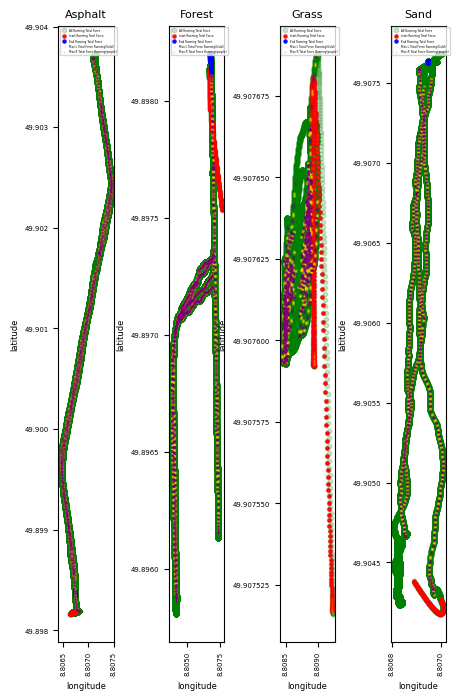

In [23]:

name_17 = [name_of_dataframe[i] for i in [0, 1, 3, 4]]
df_col = globals()[name_17[0]].copy()
col = df_col.columns[7:15].copy()
print(col)

loc_plot = 1
plt.figure(figsize=(5,8))
plt.subplots_adjust(wspace=1.0)
for i in name_17:
    df = globals()[i].copy()
    df_first = df.dropna(subset=["latitude", "longitude"]).head(300).copy()
    df_end = df.dropna(subset=["latitude", "longitude"]).tail(300).copy()
    plt.subplot(1,4,loc_plot)
    plt.scatter(df["longitude"], df["latitude"],
            s=10, color="green", alpha=0.2, linestyle='-',
            label="All Running Total Force")
    
    plt.scatter(df_first["longitude"], df_first["latitude"],
            s=5, color="red", alpha=0.9, linestyle='-',
            label="start Running Total Force")
    
    plt.scatter(df_end["longitude"], df_end["latitude"],
            s=5, color="blue", alpha=0.9, linestyle='-',
            label="End Running Total Force")   
    row_data = []
    for j in col:
        top = 0.10
        sorted_speeds = df[j].sort_values(ascending=False)
        top_1_percent = sorted_speeds.head(int(len(sorted_speeds) * top))
        mean_top_1_percent = top_1_percent.mean()
        row_data.append(mean_top_1_percent)
    print({df["foundation"].iloc[0]} , list(row_data))

    sorted_df_speed = df.sort_values(by="Total_L_Foot", ascending=False)
    top_df = sorted_df_speed.head(int(len(sorted_df_speed) * top))
    plt.scatter(top_df["longitude"], top_df["latitude"],
                s=1, color="gold", alpha=0.10, linestyle='-',
                label="Max L Total Force Running(Gold)")
    
    sorted_df_speed = df.sort_values(by="Total_R_Foot", ascending=False)
    top_df = sorted_df_speed.head(int(len(sorted_df_speed) * top))
    plt.scatter(top_df["longitude"], top_df["latitude"],
                s=1, color="purple", alpha=0.08, linestyle='-',
                label="Max R Total Force Running(purple)")
    loc_plot+=1
    plt.xlabel("longitude", fontsize=6)
    plt.xticks(rotation=90, fontsize=5)
    plt.ylabel("latitude", fontsize=6)
    plt.yticks(fontsize=5)
    ax = plt.gca()
    ax.ticklabel_format(useOffset=False, style='plain')
    plt.title(f"{df["foundation"].iloc[0]}", fontsize=8)
    plt.legend(loc='upper left', fontsize=2)


# Q4
When speed is at its highest (i.e., within the top 1% and 10% of speed values), what are the average values of **Heel**, **Midfoot**, **Forefoot**, and **Total Foot** forces?  
We first remove rows containing `null` values in the following columns:  
`['L_Heel', 'L_Midfoot', 'L_Forefoot', 'Total_L_Foot', 'R_Forefoot', 'R_Midfoot', 'R_Heel', 'Total_R_Foot', 'Speed (km/h)']`.  

Then, we sort the data in **descending order** based on `'Speed (km/h)'`.  

Using the `head()` method, we select the **top 1%** and **top 10%**of the data (i.e., the fastest samples) and compute the average values for:  
- **Heel** (average of `L_Heel` and `R_Heel`)  
- **Midfoot** (average of `L_Midfoot` and `R_Midfoot`)  (is 0)
- **Forefoot** (average of `L_Forefoot` and `R_Forefoot`)  
- **Total Foot** (average of `Total_L_Foot` and `Total_R_Foot`)

### For 1%

| Surface  | Speed (km/h) | L_Heel  | L_Midfoot | L_Forefoot | Total_L_Foot | R_Forefoot | R_Midfoot | R_Heel  | Total_R_Foot |
|----------|--------------|---------|-----------|------------|--------------|------------|-----------|---------|--------------|
| Asphalt  | 15.549       | 111.172 | 0.0       | 319.885    | 431.057      | 277.534    | 0.0       | 76.588  | 354.121      |
| Forest   | 16.482       | 98.093  | 0.0       | 316.155    | 414.248      | 301.625    | 0.0       | 87.374  | 388.999      |
| Grass    | 11.844       | 120.872 | 0.0       | 298.336    | 419.207      | 292.050    | 0.0       | 99.299  | 391.350      |
| Sand     | 14.350       | 114.306 | 0.0       | 232.371    | 346.678      | 374.875    | 0.0       | 132.046 | 506.921      |

### For 10%
| Surface  | Speed (km/h) | L_Heel  | L_Midfoot | L_Forefoot | Total_L_Foot | R_Forefoot | R_Midfoot | R_Heel  | Total_R_Foot |
|----------|--------------|---------|-----------|------------|--------------|------------|-----------|---------|--------------|
| Asphalt  | 14.861       | 101.837 | 0.0       | 305.613    | 407.450      | 308.008    | 0.0       | 82.220  | 390.228      |
| Forest   | 14.692       | 96.043  | 0.0       | 307.965    | 404.008      | 312.144    | 0.0       | 81.588  | 393.732      |
| Grass    | 10.914       | 99.406  | 0.0       | 304.997    | 404.403      | 292.250    | 0.0       | 98.568  | 390.817      |
| Sand     | 13.660       | 108.532 | 0.0       | 309.303    | 417.834      | 321.297    | 0.0       | 96.877  | 418.174      |


In [24]:
name_17 = [name_of_dataframe[i] for i in [0, 1, 3, 4]]
df_col = globals()[name_17[0]].copy()
col = df_col.columns[7:15].copy()

columns_to_check = ['L_Heel', 'L_Midfoot', 'L_Forefoot','Total_L_Foot',
                    'R_Forefoot', 'R_Midfoot', 'R_Heel', 'Total_R_Foot',
                    'Speed (km/h)']

print(col)
for i in name_17:
    df = globals()[i].copy()
    df_cleaned = df.dropna(subset=columns_to_check).copy()
    df_cleaned = df_cleaned.sort_values(by="Speed (km/h)", ascending=False)
    sorted_speeds = df_cleaned["Speed (km/h)"]
    top_1_percent = sorted_speeds.head(int(len(sorted_speeds) * 0.10))
    mean_top_1_percent = top_1_percent.mean()
    row_data = []
    row_data.append(mean_top_1_percent)
    for j in col:
        sorted_speeds = df_cleaned[j]
        top_1_percent = sorted_speeds.head(int(len(sorted_speeds) * 0.10))
        mean_top_1_percent = top_1_percent.mean()
        row_data.append(mean_top_1_percent)
    print({df["foundation"].iloc[0]} , list(row_data))



Index(['L_Heel', 'L_Midfoot', 'L_Forefoot', 'Total_L_Foot', 'R_Forefoot',
       'R_Midfoot', 'R_Heel', 'Total_R_Foot'],
      dtype='object')
{'Asphalt'} [np.float64(14.861431856005877), np.float64(101.83706343374969), np.float64(0.0), np.float64(305.6125202057311), np.float64(407.44958363948075), np.float64(308.00810433504773), np.float64(0.0), np.float64(82.22037962282636), np.float64(390.22848395787406)]
{'Forest'} [np.float64(14.691930873453437), np.float64(96.04255300609934), np.float64(0.0), np.float64(307.9654632587859), np.float64(404.0080162648853), np.float64(312.14409236131274), np.float64(0.0), np.float64(81.58817600929422), np.float64(393.732268370607)]
{'Grass'} [np.float64(10.914388059805496), np.float64(99.40568358714046), np.float64(0.0), np.float64(304.99692893401016), np.float64(404.40261252115056), np.float64(292.2497005076142), np.float64(0.0), np.float64(98.56772588832487), np.float64(390.81742639593915)]
{'Sand'} [np.float64(13.65977745288248), np.float64(108.53

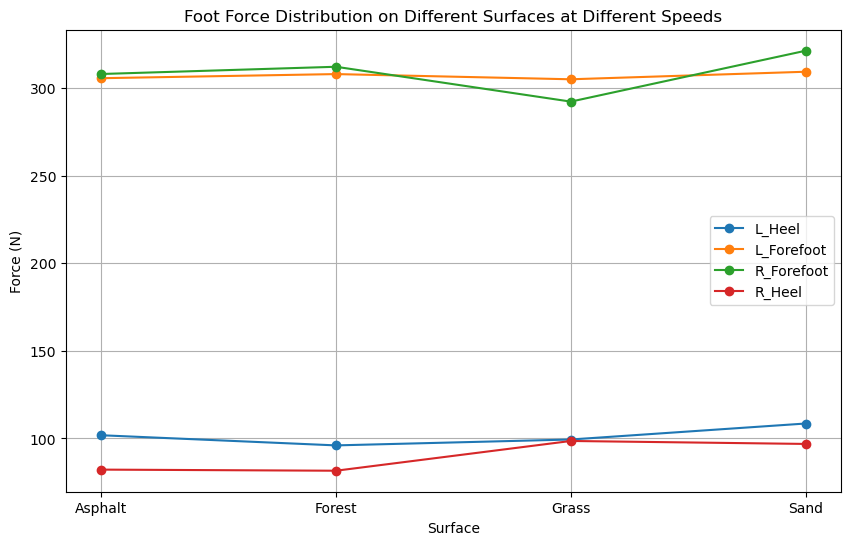

In [25]:
data = {
    "Surface": ["Asphalt", "Forest", "Grass", "Sand"],
    "Speed": [14.861, 14.692, 10.914, 13.660],
    "L_Heel": [101.837, 96.043, 99.406, 108.532],
    "L_Forefoot": [305.613, 307.965, 304.997, 309.303],
    "R_Forefoot": [308.008, 312.144, 292.250, 321.297],
    "R_Heel": [82.220, 81.588, 98.568, 96.877],

}


df = pd.DataFrame(data)


plt.figure(figsize=(10, 6))


plt.plot(df["Surface"], df["L_Heel"], label="L_Heel", marker='o')
plt.plot(df["Surface"], df["L_Forefoot"], label="L_Forefoot", marker='o')
plt.plot(df["Surface"], df["R_Forefoot"], label="R_Forefoot", marker='o')
plt.plot(df["Surface"], df["R_Heel"], label="R_Heel", marker='o')

plt.title("Foot Force Distribution on Different Surfaces at Different Speeds")
plt.xlabel("Surface")
plt.ylabel("Force (N)")
plt.legend()
plt.grid(True)


plt.show()


Index(['L_Heel', 'L_Midfoot', 'L_Forefoot', 'Total_L_Foot', 'R_Forefoot',
       'R_Midfoot', 'R_Heel', 'Total_R_Foot'],
      dtype='object')
{'Asphalt'} [np.float64(14.861431856005877), np.float64(101.83706343374969), np.float64(0.0), np.float64(305.6125202057311), np.float64(407.44958363948075), np.float64(308.00810433504773), np.float64(0.0), np.float64(82.22037962282636), np.float64(390.22848395787406)]
{'Forest'} [np.float64(14.691930873453437), np.float64(96.04255300609934), np.float64(0.0), np.float64(307.9654632587859), np.float64(404.0080162648853), np.float64(312.14409236131274), np.float64(0.0), np.float64(81.58817600929422), np.float64(393.732268370607)]
{'Grass'} [np.float64(10.914388059805496), np.float64(99.40568358714046), np.float64(0.0), np.float64(304.99692893401016), np.float64(404.40261252115056), np.float64(292.2497005076142), np.float64(0.0), np.float64(98.56772588832487), np.float64(390.81742639593915)]
{'Sand'} [np.float64(13.65977745288248), np.float64(108.53

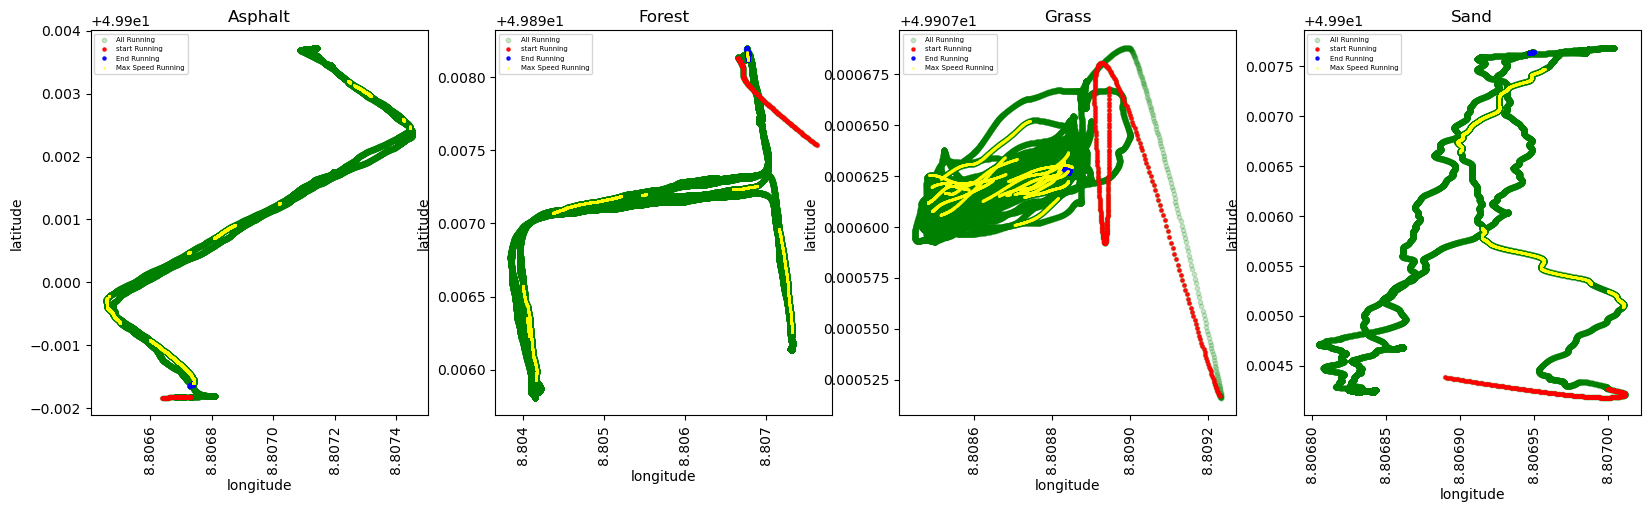

In [26]:

name_17 = [name_of_dataframe[i] for i in [0, 1, 3, 4]]
df_col = globals()[name_17[0]].copy()
col = df_col.columns[7:15].copy()

columns_to_check = ['L_Heel', 'L_Midfoot', 'L_Forefoot','Total_L_Foot',
                    'R_Forefoot', 'R_Midfoot', 'R_Heel', 'Total_R_Foot',
                    'Speed (km/h)']

loc_plot = 1
plt.figure(figsize=(20,5))
print(col)
for i in name_17:
    df = globals()[i].copy()
    df_first = df.dropna(subset=["latitude", "longitude"]).head(300).copy()
    df_end = df.dropna(subset=["latitude", "longitude"]).tail(300).copy()
    plt.subplot(1,4,loc_plot)
    plt.scatter(df["longitude"], df["latitude"],
            s=10, color="green", alpha=0.2, linestyle='-',
            label="All Running")
    plt.scatter(df_first["longitude"], df_first["latitude"],
            s=5, color="red", alpha=0.9, linestyle='-',
            label="start Running")
    plt.scatter(df_end["longitude"], df_end["latitude"],
            s=5, color="blue", alpha=0.9, linestyle='-',
            label="End Running")
    top = 0.10
    df_cleaned = df.dropna(subset=columns_to_check).copy()
    df_cleaned = df_cleaned.sort_values(by="Speed (km/h)", ascending=False)
    sorted_speeds = df_cleaned["Speed (km/h)"]
    top_1_percent = sorted_speeds.head(int(len(sorted_speeds) * top))
    mean_top_1_percent = top_1_percent.mean()
    row_data = []
    row_data.append(mean_top_1_percent)
    for j in col:
        sorted_speeds = df_cleaned[j]
        top_1_percent = sorted_speeds.head(int(len(sorted_speeds) * top))
        mean_top_1_percent = top_1_percent.mean()
        row_data.append(mean_top_1_percent)
    print({df["foundation"].iloc[0]} , list(row_data))
    sorted_df_speed = df.sort_values(by="Speed (km/h)", ascending=False)
    top_df = sorted_df_speed.head(int(len(sorted_df_speed) * top))
    plt.scatter(top_df["longitude"], top_df["latitude"],
            s=1, color="yellow", alpha=0.5, linestyle='-',
            label="Max Speed Running")
    loc_plot+=1
    plt.xlabel("longitude")
    plt.xticks(rotation=90)
    plt.ylabel("latitude")
    plt.title(f"{df["foundation"].iloc[0]}")
    plt.legend(loc='upper left', fontsize=5)

Index(['L_Heel', 'L_Midfoot', 'L_Forefoot', 'Total_L_Foot', 'R_Forefoot',
       'R_Midfoot', 'R_Heel', 'Total_R_Foot'],
      dtype='object')
{'Asphalt'} [np.float64(14.861431856005877), np.float64(101.83706343374969), np.float64(0.0), np.float64(305.6125202057311), np.float64(407.44958363948075), np.float64(308.00810433504773), np.float64(0.0), np.float64(82.22037962282636), np.float64(390.22848395787406)]
{'Forest'} [np.float64(14.691930873453437), np.float64(96.04255300609934), np.float64(0.0), np.float64(307.9654632587859), np.float64(404.0080162648853), np.float64(312.14409236131274), np.float64(0.0), np.float64(81.58817600929422), np.float64(393.732268370607)]
{'Grass'} [np.float64(10.914388059805496), np.float64(99.40568358714046), np.float64(0.0), np.float64(304.99692893401016), np.float64(404.40261252115056), np.float64(292.2497005076142), np.float64(0.0), np.float64(98.56772588832487), np.float64(390.81742639593915)]
{'Sand'} [np.float64(13.65977745288248), np.float64(108.53

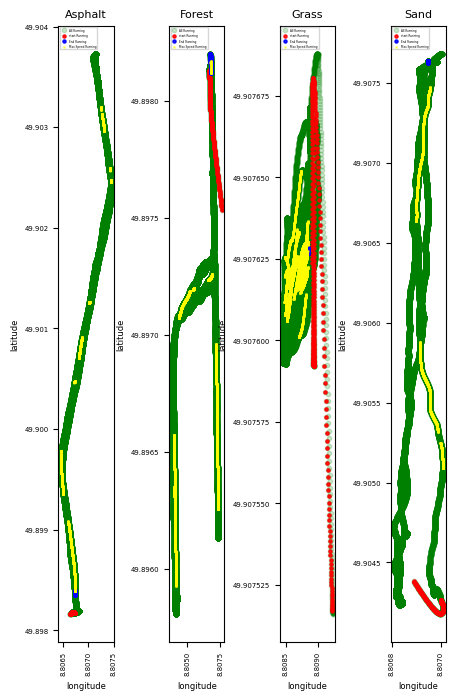

In [27]:

name_17 = [name_of_dataframe[i] for i in [0, 1, 3, 4]]
df_col = globals()[name_17[0]].copy()
col = df_col.columns[7:15].copy()

columns_to_check = ['L_Heel', 'L_Midfoot', 'L_Forefoot','Total_L_Foot',
                    'R_Forefoot', 'R_Midfoot', 'R_Heel', 'Total_R_Foot',
                    'Speed (km/h)']

loc_plot = 1
plt.figure(figsize=(5,8))
plt.subplots_adjust(wspace=1.0)
print(col)
for i in name_17:
    df = globals()[i].copy()
    df_first = df.dropna(subset=["latitude", "longitude"]).head(300).copy()
    df_end = df.dropna(subset=["latitude", "longitude"]).tail(300).copy()
    plt.subplot(1,4,loc_plot)
    plt.scatter(df["longitude"], df["latitude"],
            s=10, color="green", alpha=0.2, linestyle='-',
            label="All Running")
    plt.scatter(df_first["longitude"], df_first["latitude"],
            s=5, color="red", alpha=0.9, linestyle='-',
            label="start Running")
    plt.scatter(df_end["longitude"], df_end["latitude"],
            s=5, color="blue", alpha=0.9, linestyle='-',
            label="End Running")
    top = 0.10
    df_cleaned = df.dropna(subset=columns_to_check).copy()
    df_cleaned = df_cleaned.sort_values(by="Speed (km/h)", ascending=False)
    sorted_speeds = df_cleaned["Speed (km/h)"]
    top_1_percent = sorted_speeds.head(int(len(sorted_speeds) * top))
    mean_top_1_percent = top_1_percent.mean()
    row_data = []
    row_data.append(mean_top_1_percent)
    for j in col:
        sorted_speeds = df_cleaned[j]
        top_1_percent = sorted_speeds.head(int(len(sorted_speeds) * top))
        mean_top_1_percent = top_1_percent.mean()
        row_data.append(mean_top_1_percent)
    print({df["foundation"].iloc[0]} , list(row_data))
    sorted_df_speed = df.sort_values(by="Speed (km/h)", ascending=False)
    top_df = sorted_df_speed.head(int(len(sorted_df_speed) * top))
    plt.scatter(top_df["longitude"], top_df["latitude"],
            s=1, color="yellow", alpha=0.5, linestyle='-',
            label="Max Speed Running")
    loc_plot+=1
    plt.xlabel("longitude", fontsize=6)
    plt.xticks(rotation=90, fontsize=5)
    plt.ylabel("latitude", fontsize=6)
    plt.yticks(fontsize=5)
    ax = plt.gca()
    ax.ticklabel_format(useOffset=False, style='plain')
    plt.title(f"{df["foundation"].iloc[0]}", fontsize=8)
    plt.legend(loc='upper left', fontsize=2)


Vorfußkraft-Impuls während der Standphase

In [28]:

df_Asphalt = Asphalt_S07_01_341_Date_2025_11_17_Time_10_09_36.copy()


#----------- Left foot----------------
# select columns Time_x and L_Forefoot
# Time_x: start 0 with a step of 0.01 seconds
# L_Forefoot : force 
df_forcefoot_L_Asphalt = df[["Time_x", "L_Forefoot"]].copy()

# drop NA row
df_forcefoot_L_Asphalt = df_forcefoot_L_Asphalt.dropna()

# Select a range (secend 10 to 400)
df_forcefoot_L_Asphalt = df_forcefoot_L_Asphalt.iloc[1000:40001].reset_index().drop(columns = "index")

# create an empty column to indicate whether the foot is on the ground or in the air
df_forcefoot_L_Asphalt["category_moving"] = ""

# create a mask such that if the force is less than 100,
# the foot is in the air,
# otherwise, the foot is on the ground.
mask_step = 100

# np.where( if (mask), True, False)
df_forcefoot_L_Asphalt["category_moving"] = np.where(df_forcefoot_L_Asphalt["L_Forefoot"].ge(mask_step) ,"ground","air")

# select first and end air index
# if end of data are graund, drop
min_air_index = df_forcefoot_L_Asphalt[df_forcefoot_L_Asphalt["category_moving"].eq("air")].index.min()
max_air_index = df_forcefoot_L_Asphalt[df_forcefoot_L_Asphalt["category_moving"].eq("air")].index.max()
df_forcefoot_L_Asphalt = df_forcefoot_L_Asphalt.iloc[min_air_index:max_air_index].reset_index().drop(columns = "index")

# Finding the start of a step: the start of a step is the first moment the foot
# contacts the ground until the next time the same foot contacts the ground again
# mask condition
condition = ((df_forcefoot_L_Asphalt["category_moving"] == "ground") &
             (df_forcefoot_L_Asphalt["category_moving"].shift(1) == "air"))
df_forcefoot_L_Asphalt.loc[condition, "action"] = "contact"
min_condition = df_forcefoot_L_Asphalt[df_forcefoot_L_Asphalt["action"].eq("contact")].index.min()
df_forcefoot_L_Asphalt = df_forcefoot_L_Asphalt.iloc[min_condition:].reset_index().drop(columns = "index")
df_forcefoot_L_Asphalt.to_csv("C:/Users/abolhassni/Desktop/df_forcefoot_L_Asphalt.csv", index=False)
#----------- left foot----------------


# filter dataframe when action is contact
contact_indices_L = df_forcefoot_L_Asphalt[df_forcefoot_L_Asphalt["action"].eq("contact")].index.tolist()

# tow list for save data
total_forces_L_Asphalt = []
time_intervals_L_Asphalt = []
impuls_L=[]

# find 2 "contact" and find total force and time
for i in range(len(contact_indices_L) - 1):
    start_idx = contact_indices_L[i]
    end_idx = contact_indices_L[i + 1]

    # total forcefoot
    df_f = df_forcefoot_L_Asphalt.loc[start_idx : end_idx - 1].copy()
    df_f_graund = df_f[df_f["category_moving"].eq("ground")]
    force_sum = df_f_graund["L_Forefoot"].sum()
    impuls_one_step=force_sum * 0.01
    
    # time
    time_diff = df_forcefoot_L_Asphalt.loc[end_idx]["Time_x"] - df_forcefoot_L_Asphalt.loc[start_idx]["Time_x"]
    
    # add to list
    total_forces_L_Asphalt.append(force_sum)
    time_intervals_L_Asphalt.append(time_diff)
    impuls_L.append(impuls_one_step)

print("----------end-------------")

----------end-------------


In [29]:

#----------- Right foot----------------
# select columns Time_x and L_Forefoot
# Time_x: start 0 with a step of 0.01 seconds
# L_Forefoot : force 
df_forcefoot_R_Asphalt = df[["Time_x", "R_Forefoot"]].copy()

# drop NA row
df_forcefoot_R_Asphalt = df_forcefoot_R_Asphalt.dropna()

# Select a range (secend 10 to 400)
df_forcefoot_R_Asphalt = df_forcefoot_R_Asphalt.iloc[1000:40001].reset_index().drop(columns = "index")

# create an empty column to indicate whether the foot is on the ground or in the air
df_forcefoot_R_Asphalt["category_moving"] = ""


# np.where( if (mask), True, False)
df_forcefoot_R_Asphalt["category_moving"] = np.where(df_forcefoot_R_Asphalt["R_Forefoot"].ge(mask_step) ,"ground","air")

# select first and end air index
# if end of data are graund, drop
min_air_index = df_forcefoot_R_Asphalt[df_forcefoot_R_Asphalt["category_moving"].eq("air")].index.min()
max_air_index = df_forcefoot_R_Asphalt[df_forcefoot_R_Asphalt["category_moving"].eq("air")].index.max()
df_forcefoot_R_Asphalt = df_forcefoot_R_Asphalt.iloc[min_air_index:max_air_index].reset_index().drop(columns = "index")

# Finding the start of a step: the start of a step is the first moment the foot
# contacts the ground until the next time the same foot contacts the ground again
# mask condition
condition = ((df_forcefoot_R_Asphalt["category_moving"] == "ground") &
             (df_forcefoot_R_Asphalt["category_moving"].shift(1) == "air"))
df_forcefoot_R_Asphalt.loc[condition, "action"] = "contact"
min_condition = df_forcefoot_R_Asphalt[df_forcefoot_R_Asphalt["action"].eq("contact")].index.min()
df_forcefoot_R_Asphalt = df_forcefoot_R_Asphalt.iloc[min_condition:].reset_index().drop(columns = "index")
df_forcefoot_R_Asphalt.to_csv("C:/Users/abolhassni/Desktop/df_forcefoot_R_Asphalt.csv", index=False)
#----------- Right foot----------------

# filter dataframe when action is contact
contact_indices_R = df_forcefoot_R_Asphalt[df_forcefoot_R_Asphalt["action"].eq("contact")].index.tolist()
contact_indices_R
# tow list for save data
total_forces_R_Asphalt = []
time_intervals_R_Asphalt = []
impuls_R=[]

# find 2 "contact" and find total force and time
for i in range(len(contact_indices_R) - 1):
    start_idx = contact_indices_R[i]
    end_idx = contact_indices_R[i + 1]
                                                                                                                                                                                                                                                                                                                                                                                                      
#     # total forcefoot
    df_f = df_forcefoot_R_Asphalt.loc[start_idx : end_idx - 1].copy()
    df_f_graund = df_f[df_f["category_moving"].eq("ground")]
    force_sum = df_f_graund["R_Forefoot"].sum()
    impuls_one_step=force_sum * 0.01
    
#     # time
    time_diff = df_forcefoot_R_Asphalt.loc[end_idx]["Time_x"] - df_forcefoot_R_Asphalt.loc[start_idx]["Time_x"]
    
#     # add to list
    total_forces_R_Asphalt.append(force_sum)
    time_intervals_R_Asphalt.append(time_diff)
    impuls_R.append(impuls_one_step)

print("----------end-------------")


----------end-------------


In [30]:
df_L = pd.DataFrame({
    "Time_L": time_intervals_L_Asphalt,
    "Total_L_forcefoot": total_forces_L_Asphalt,
    "impuls_L": impuls_L
})

df_R = pd.DataFrame({
    "Time_R": time_intervals_R_Asphalt,
    "Total_R_forcefoot": total_forces_R_Asphalt,
    "impuls_R": impuls_R
})

df_L[["Time_R", "Total_R_forcefoot", "impuls_R"]] = df_R[["Time_R", "Total_R_forcefoot", "impuls_R"]]

df_all = df_L
df_all.to_csv("C:/Users/abolhassni/Desktop/df_all_asphalt.csv", index=False)


In [31]:
df = pd.read_csv(r"C:/Users/abolhassni/Desktop/df_all_asphalt.csv")
L = df["impuls_L"]
R = df["impuls_R"]

L_Sorted = L.sort_values().reset_index(drop=True)
R_Sorted = R.sort_values().reset_index(drop=True)

df_sorted = pd.DataFrame({"impuls_L": L_Sorted, "impuls_R": R_Sorted})

df_sorted["L_greater_than_R"] = df_sorted["impuls_L"] > df_sorted["impuls_R"]
df_sorted["R_greater_than_L"] = df_sorted["impuls_R"] > df_sorted["impuls_L"]

print(df_sorted["R_greater_than_L"].sum())
print(df_sorted["L_greater_than_R"].sum())


410
29


In [32]:

df_Forest = Forest_S07_02_492_Date_2025_11_17_Time_09_53_52.copy()


#----------- Left foot----------------
# select columns Time_x and L_Forefoot
# Time_x: start 0 with a step of 0.01 seconds
# L_Forefoot : force 
df_forcefoot_L_Forest = df_Forest[["Time_x", "L_Forefoot"]].copy()

# drop NA row
df_forcefoot_L_Forest = df_forcefoot_L_Forest.dropna()

# Select a range (secend 10 to 400)
df_forcefoot_L_Forest = df_forcefoot_L_Forest.iloc[1000:40001].reset_index().drop(columns = "index")

# create an empty column to indicate whether the foot is on the ground or in the air
df_forcefoot_L_Forest["category_moving"] = ""

# create a mask such that if the force is less than 100,
# the foot is in the air,
# otherwise, the foot is on the ground.
mask_step = 100

# np.where( if (mask), True, False)
df_forcefoot_L_Forest["category_moving"] = np.where(df_forcefoot_L_Forest["L_Forefoot"].ge(mask_step) ,"ground","air")

# select first and end air index
# if end of data are graund, drop
min_air_index = df_forcefoot_L_Forest[df_forcefoot_L_Forest["category_moving"].eq("air")].index.min()
max_air_index = df_forcefoot_L_Forest[df_forcefoot_L_Forest["category_moving"].eq("air")].index.max()
df_forcefoot_L_Forest = df_forcefoot_L_Forest.iloc[min_air_index:max_air_index].reset_index().drop(columns = "index")

# Finding the start of a step: the start of a step is the first moment the foot
# contacts the ground until the next time the same foot contacts the ground again
# mask condition
condition = ((df_forcefoot_L_Forest["category_moving"] == "ground") &
             (df_forcefoot_L_Forest["category_moving"].shift(1) == "air"))
df_forcefoot_L_Forest.loc[condition, "action"] = "contact"
min_condition = df_forcefoot_L_Forest[df_forcefoot_L_Forest["action"].eq("contact")].index.min()
df_forcefoot_L_Forest = df_forcefoot_L_Forest.iloc[min_condition:].reset_index().drop(columns = "index")
df_forcefoot_L_Forest.to_csv("C:/Users/abolhassni/Desktop/df_forcefoot_L_Forest.csv", index=False)
#----------- left foot----------------


# filter dataframe when action is contact
contact_indices_L = df_forcefoot_L_Forest[df_forcefoot_L_Forest["action"].eq("contact")].index.tolist()

# tow list for save data
total_forces_L_Forest = []
time_intervals_L_Forest = []
impuls_L=[]

# find 2 "contact" and find total force and time
for i in range(len(contact_indices_L) - 1):
    start_idx = contact_indices_L[i]
    end_idx = contact_indices_L[i + 1]

    # total forcefoot
    df_f = df_forcefoot_L_Forest.loc[start_idx : end_idx - 1].copy()
    df_f_graund = df_f[df_f["category_moving"].eq("ground")]
    force_sum = df_f_graund["L_Forefoot"].sum()
    impuls_one_step=force_sum * 0.01

    # time
    time_diff = df_forcefoot_L_Forest.loc[end_idx]["Time_x"] - df_forcefoot_L_Forest.loc[start_idx]["Time_x"]
    
    # add to list
    total_forces_L_Forest.append(force_sum)
    time_intervals_L_Forest.append(time_diff)
    impuls_L.append(impuls_one_step)

print("----------end-------------")

----------end-------------


In [33]:

#----------- Right foot----------------
# select columns Time_x and L_Forefoot
# Time_x: start 0 with a step of 0.01 seconds
# L_Forefoot : force
df_forcefoot_R_Forest = df_Forest[["Time_x", "R_Forefoot"]].copy()

# drop NA row
df_forcefoot_R_Forest = df_forcefoot_R_Forest.dropna()

# Select a range (secend 10 to 400)
df_forcefoot_R_Forest = df_forcefoot_R_Forest.iloc[1000:40001].reset_index().drop(columns = "index")

# create an empty column to indicate whether the foot is on the ground or in the air
df_forcefoot_R_Forest["category_moving"] = ""


# np.where( if (mask), True, False)
df_forcefoot_R_Forest["category_moving"] = np.where(df_forcefoot_R_Forest["R_Forefoot"].ge(mask_step) ,"ground","air")

# select first and end air index
# if end of data are graund, drop
min_air_index = df_forcefoot_R_Forest[df_forcefoot_R_Forest["category_moving"].eq("air")].index.min()
max_air_index = df_forcefoot_R_Forest[df_forcefoot_R_Forest["category_moving"].eq("air")].index.max()
df_forcefoot_R_Forest = df_forcefoot_R_Forest.iloc[min_air_index:max_air_index].reset_index().drop(columns = "index")

# Finding the start of a step: the start of a step is the first moment the foot
# contacts the ground until the next time the same foot contacts the ground again
# mask condition
condition = ((df_forcefoot_R_Forest["category_moving"] == "ground") &
             (df_forcefoot_R_Forest["category_moving"].shift(1) == "air"))
df_forcefoot_R_Forest.loc[condition, "action"] = "contact"
min_condition = df_forcefoot_R_Forest[df_forcefoot_R_Forest["action"].eq("contact")].index.min()
df_forcefoot_R_Forest = df_forcefoot_R_Forest.iloc[min_condition:].reset_index().drop(columns = "index")
df_forcefoot_R_Forest.to_csv("C:/Users/abolhassni/Desktop/df_forcefoot_R_Forest.csv", index=False)
#----------- Right foot----------------

# filter dataframe when action is contact
contact_indices_R = df_forcefoot_R_Forest[df_forcefoot_R_Forest["action"].eq("contact")].index.tolist()
contact_indices_R
# tow list for save data
total_forces_R_Forest = []
time_intervals_R_Forest = []
impuls_R=[]

# find 2 "contact" and find total force and time
for i in range(len(contact_indices_R) - 1):
    start_idx = contact_indices_R[i]
    end_idx = contact_indices_R[i + 1]
                                                                                                                                                                                                                                                                                                                                                                                                      
#     # total forcefoot
    df_f = df_forcefoot_R_Forest.loc[start_idx : end_idx - 1].copy()
    df_f_graund = df_f[df_f["category_moving"].eq("ground")]
    force_sum = df_f_graund["R_Forefoot"].sum()
    impuls_one_step=force_sum * 0.01
    
#     # time
    time_diff = df_forcefoot_R_Forest.loc[end_idx]["Time_x"] - df_forcefoot_R_Forest.loc[start_idx]["Time_x"]
    
#     # add to list
    total_forces_R_Forest.append(force_sum)
    time_intervals_R_Forest.append(time_diff)
    impuls_R.append(impuls_one_step)

print("----------end-------------")


----------end-------------


In [34]:
df_L = pd.DataFrame({"Time_L": time_intervals_L_Forest,
                    "Total_L_forcefoot": total_forces_L_Forest,
                    "Impuls_L" : impuls_L})

df_R = pd.DataFrame({"Time_R": time_intervals_R_Forest,
                    "Total_R_forcefoot": total_forces_R_Forest,
                    "Impuls_R" : impuls_R})

df_L[["Time_R", "Total_R_forcefoot", "Impuls_R"]] = df_R[["Time_R","Total_R_forcefoot", "Impuls_R"]]
df_all = df_L
df_all.to_csv("C:/Users/abolhassni/Desktop/df_all_ّForest.csv", index=False)

In [35]:
df=pd.read_csv(r"C:/Users/abolhassni/Desktop/df_all_ّForest.csv")
L=df["Impuls_L"]
R=df["Impuls_R"]

L_Sorted=L.sort_values().reset_index(drop=True)
R_Sorted=R.sort_values().reset_index(drop=True)

df_sorted=pd.DataFrame({"Impuls_L": L_Sorted, "Impuls_R":R_Sorted})

df_sorted["L_greater_than_R"]=(df_sorted["Impuls_L"]> df_sorted["Impuls_R"])
df_sorted["R_greater_than_L"]=(df_sorted["Impuls_R"]> df_sorted["Impuls_L"])


print(df_sorted["R_greater_than_L"].sum())
print(df_sorted["L_greater_than_R"].sum())

398
20


In [36]:

df_Sand =Sand__S07_01_073_Date_2025_11_17_Time_09_15_09.copy()


#----------- Left foot----------------
# select columns Time_x and L_Forefoot
# Time_x: start 0 with a step of 0.01 seconds
# L_Forefoot : force 
df_forcefoot_L_Sand = df_Sand[["Time_x", "L_Forefoot"]].copy()

# drop NA row
df_forcefoot_L_Sand = df_forcefoot_L_Sand.dropna()

# Select a range (secend 10 to 400)
df_forcefoot_L_Sand = df_forcefoot_L_Sand.iloc[1000:40001].reset_index().drop(columns = "index")

# create an empty column to indicate whether the foot is on the ground or in the air
df_forcefoot_L_Sand["category_moving"] = ""

# create a mask such that if the force is less than 100,
# the foot is in the air,
# otherwise, the foot is on the ground.
mask_step = 100

# np.where( if (mask), True, False)
df_forcefoot_L_Sand["category_moving"] = np.where(df_forcefoot_L_Sand["L_Forefoot"].ge(mask_step) ,"ground","air")

# select first and end air index
# if end of data are graund, drop
min_air_index = df_forcefoot_L_Sand[df_forcefoot_L_Sand["category_moving"].eq("air")].index.min()
max_air_index = df_forcefoot_L_Sand[df_forcefoot_L_Sand["category_moving"].eq("air")].index.max()
df_forcefoot_L_Sand = df_forcefoot_L_Sand.iloc[min_air_index:max_air_index].reset_index().drop(columns = "index")

# Finding the start of a step: the start of a step is the first moment the foot
# contacts the ground until the next time the same foot contacts the ground again
# mask condition
condition = ((df_forcefoot_L_Sand["category_moving"] == "ground") &
             (df_forcefoot_L_Sand["category_moving"].shift(1) == "air"))
df_forcefoot_L_Sand.loc[condition, "action"] = "contact"
min_condition = df_forcefoot_L_Sand[df_forcefoot_L_Sand["action"].eq("contact")].index.min()
df_forcefoot_L_Sand = df_forcefoot_L_Sand.iloc[min_condition:].reset_index().drop(columns = "index")
df_forcefoot_L_Sand.to_csv("C:/Users/abolhassni/Desktop/df_forcefoot_L_Sand.csv", index=False)
#----------- left foot----------------


# filter dataframe when action is contact
contact_indices_L = df_forcefoot_L_Sand[df_forcefoot_L_Sand["action"].eq("contact")].index.tolist()

# tow list for save data
total_forces_L_Sand = []
time_intervals_L_Sand = []

# find 2 "contact" and find total force and time
for i in range(len(contact_indices_L) - 1):
    start_idx = contact_indices_L[i]
    end_idx = contact_indices_L[i + 1]

    # total forcefoot
    df_f = df_forcefoot_L_Sand.loc[start_idx : end_idx - 1].copy()
    df_f_graund = df_f[df_f["category_moving"].eq("ground")]
    force_sum = df_f_graund["L_Forefoot"].sum()
    
    # time
    time_diff = df_forcefoot_L_Sand.loc[end_idx]["Time_x"] - df_forcefoot_L_Sand.loc[start_idx]["Time_x"]
    
    # add to list
    total_forces_L_Sand.append(force_sum)
    time_intervals_L_Sand.append(time_diff)

print("----------end-------------")

----------end-------------


In [37]:

#----------- Right foot----------------
# select columns Time_x and L_Forefoot
# Time_x: start 0 with a step of 0.01 seconds
# L_Forefoot : force 
df_forcefoot_R_Sand = df_Sand[["Time_x", "R_Forefoot"]].copy()

# drop NA row
df_forcefoot_R_Sand = df_forcefoot_R_Sand.dropna()

# Select a range (secend 10 to 400)
df_forcefoot_R_Sand = df_forcefoot_R_Sand.iloc[1000:40001].reset_index().drop(columns = "index")

# create an empty column to indicate whether the foot is on the ground or in the air
df_forcefoot_R_Sand["category_moving"] = ""


# np.where( if (mask), True, False)
df_forcefoot_R_Sand["category_moving"] = np.where(df_forcefoot_R_Sand["R_Forefoot"].ge(mask_step) ,"ground","air")

# select first and end air index
# if end of data are graund, drop
min_air_index = df_forcefoot_R_Sand[df_forcefoot_R_Sand["category_moving"].eq("air")].index.min()
max_air_index = df_forcefoot_R_Sand[df_forcefoot_R_Sand["category_moving"].eq("air")].index.max()
df_forcefoot_R_Sand = df_forcefoot_R_Sand.iloc[min_air_index:max_air_index].reset_index().drop(columns = "index")

# Finding the start of a step: the start of a step is the first moment the foot
# contacts the ground until the next time the same foot contacts the ground again
# mask condition
condition = ((df_forcefoot_R_Sand["category_moving"] == "ground") &
             (df_forcefoot_R_Sand["category_moving"].shift(1) == "air"))
df_forcefoot_R_Sand.loc[condition, "action"] = "contact"
min_condition = df_forcefoot_R_Sand[df_forcefoot_R_Sand["action"].eq("contact")].index.min()
df_forcefoot_R_Sand = df_forcefoot_R_Sand.iloc[min_condition:].reset_index().drop(columns = "index")
df_forcefoot_R_Sand.to_csv("C:/Users/abolhassni/Desktop/df_forcefoot_R_Sand.csv", index=False)
#----------- Right foot----------------

# filter dataframe when action is contact
contact_indices_R = df_forcefoot_R_Sand[df_forcefoot_R_Sand["action"].eq("contact")].index.tolist()
contact_indices_R
# tow list for save data
total_forces_R_Sand = []
time_intervals_R_Sand = []

# find 2 "contact" and find total force and time
for i in range(len(contact_indices_R) - 1):
    start_idx = contact_indices_R[i]
    end_idx = contact_indices_R[i + 1]
                                                                                                                                                                                                                                                                                                                                                                                                      
#     # total forcefoot
    df_f = df_forcefoot_R_Sand.loc[start_idx : end_idx - 1].copy()
    df_f_graund = df_f[df_f["category_moving"].eq("ground")]
    force_sum = df_f_graund["R_Forefoot"].sum()
    
#     # time
    time_diff = df_forcefoot_R_Sand.loc[end_idx]["Time_x"] - df_forcefoot_R_Sand.loc[start_idx]["Time_x"]
    
#     # add to list
    total_forces_R_Sand.append(force_sum)
    time_intervals_R_Sand.append(time_diff)

print("----------end-------------")


----------end-------------


In [38]:
df_L = pd.DataFrame({"Time_L": time_intervals_L_Sand,
                    "Total_L_forcefoot": total_forces_L_Sand,})

df_R = pd.DataFrame({"Time_R": time_intervals_R_Sand,
                    "Total_R_forcefoot": total_forces_R_Sand,})

df_L[["Time_R", "Total_R_forcefoot"]] = df_R[["Time_R","Total_R_forcefoot"]]
df_all = df_L
df_all.to_csv("C:/Users/abolhassni/Desktop/df_all_Sand.csv", index=False)

In [39]:
df=pd.read_csv(r"C:/Users/abolhassni/Desktop/df_all_Sand.csv")
L=df["Total_L_forcefoot"]
R=df["Total_R_forcefoot"]

L_Sorted=L.sort_values().reset_index(drop=True)
R_Sorted=R.sort_values().reset_index(drop=True)

df_sorted=pd.DataFrame({"Total_L_forcefoot": L_Sorted, "Total_R_forcefoot":R_Sorted})

df_sorted["L_greater_than_R"]=(df_sorted["Total_L_forcefoot"]> df_sorted["Total_R_forcefoot"])
df_sorted["R_greater_than_L"]=(df_sorted["Total_R_forcefoot"]> df_sorted["Total_L_forcefoot"])


print(df_sorted["R_greater_than_L"].sum())
print(df_sorted["L_greater_than_R"].sum())

410
29


In [40]:

df_Grass =Grass_S07_01_980_Date_2025_11_17_Time_09_27_24.copy()


#----------- Left foot----------------
# select columns Time_x and L_Forefoot
# Time_x: start 0 with a step of 0.01 seconds
# L_Forefoot : force 
df_forcefoot_L_Grass = df_Grass[["Time_x", "L_Forefoot"]].copy()

# drop NA row
df_forcefoot_L_Grass = df_forcefoot_L_Grass.dropna()

# Select a range (secend 10 to 400)
df_forcefoot_L_Grass = df_forcefoot_L_Grass.iloc[1000:40001].reset_index().drop(columns = "index")

# create an empty column to indicate whether the foot is on the ground or in the air
df_forcefoot_L_Grass["category_moving"] = ""

# create a mask such that if the force is less than 100,
# the foot is in the air,
# otherwise, the foot is on the ground.
mask_step = 100

# np.where( if (mask), True, False)
df_forcefoot_L_Grass["category_moving"] = np.where(df_forcefoot_L_Grass["L_Forefoot"].ge(mask_step) ,"ground","air")

# select first and end air index
# if end of data are graund, drop
min_air_index = df_forcefoot_L_Grass[df_forcefoot_L_Grass["category_moving"].eq("air")].index.min()
max_air_index = df_forcefoot_L_Grass[df_forcefoot_L_Grass["category_moving"].eq("air")].index.max()
df_forcefoot_L_Grass = df_forcefoot_L_Grass.iloc[min_air_index:max_air_index].reset_index().drop(columns = "index")

# Finding the start of a step: the start of a step is the first moment the foot
# contacts the ground until the next time the same foot contacts the ground again
# mask condition
condition = ((df_forcefoot_L_Grass["category_moving"] == "ground") &
             (df_forcefoot_L_Grass["category_moving"].shift(1) == "air"))
df_forcefoot_L_Grass.loc[condition, "action"] = "contact"
min_condition = df_forcefoot_L_Grass[df_forcefoot_L_Grass["action"].eq("contact")].index.min()
df_forcefoot_L_Grass = df_forcefoot_L_Grass.iloc[min_condition:].reset_index().drop(columns = "index")
df_forcefoot_L_Grass.to_csv("C:/Users/abolhassni/Desktop/df_forcefoot_L_Grass.csv", index=False)
#----------- left foot----------------


# filter dataframe when action is contact
contact_indices_L = df_forcefoot_L_Grass[df_forcefoot_L_Grass["action"].eq("contact")].index.tolist()

# tow list for save data
total_forces_L_Grass = []
time_intervals_L_Grass = []

# find 2 "contact" and find total force and time
for i in range(len(contact_indices_L) - 1):
    start_idx = contact_indices_L[i]
    end_idx = contact_indices_L[i + 1]

    # total forcefoot
    df_f = df_forcefoot_L_Grass.loc[start_idx : end_idx - 1].copy()
    df_f_graund = df_f[df_f["category_moving"].eq("ground")]
    force_sum = df_f_graund["L_Forefoot"].sum()
    
    # time
    time_diff = df_forcefoot_L_Grass.loc[end_idx]["Time_x"] - df_forcefoot_L_Grass.loc[start_idx]["Time_x"]
    
    # add to list
    total_forces_L_Grass.append(force_sum)
    time_intervals_L_Grass.append(time_diff)

print("----------end-------------")

----------end-------------


In [41]:

#----------- Right foot----------------
# select columns Time_x and L_Forefoot
# Time_x: start 0 with a step of 0.01 seconds
# L_Forefoot : force 
df_forcefoot_R_Grass = df_Grass[["Time_x", "R_Forefoot"]].copy()

# drop NA row
df_forcefoot_R_Grass = df_forcefoot_R_Grass.dropna()

# Select a range (secend 10 to 400)
df_forcefoot_R_Grass = df_forcefoot_R_Grass.iloc[1000:40001].reset_index().drop(columns = "index")

# create an empty column to indicate whether the foot is on the ground or in the air
df_forcefoot_R_Grass["category_moving"] = ""


# np.where( if (mask), True, False)
df_forcefoot_R_Grass["category_moving"] = np.where(df_forcefoot_R_Grass["R_Forefoot"].ge(mask_step) ,"ground","air")

# select first and end air index
# if end of data are graund, drop
min_air_index = df_forcefoot_R_Grass[df_forcefoot_R_Grass["category_moving"].eq("air")].index.min()
max_air_index = df_forcefoot_R_Grass[df_forcefoot_R_Grass["category_moving"].eq("air")].index.max()
df_forcefoot_R_Grass = df_forcefoot_R_Grass.iloc[min_air_index:max_air_index].reset_index().drop(columns = "index")

# Finding the start of a step: the start of a step is the first moment the foot
# contacts the ground until the next time the same foot contacts the ground again
# mask condition
condition = ((df_forcefoot_R_Grass["category_moving"] == "ground") &
             (df_forcefoot_R_Grass["category_moving"].shift(1) == "air"))
df_forcefoot_R_Grass.loc[condition, "action"] = "contact"
min_condition = df_forcefoot_R_Grass[df_forcefoot_R_Grass["action"].eq("contact")].index.min()
df_forcefoot_R_Grass = df_forcefoot_R_Grass.iloc[min_condition:].reset_index().drop(columns = "index")
df_forcefoot_R_Grass.to_csv("C:/Users/abolhassni/Desktop/df_forcefoot_R_Grass.csv", index=False)
#----------- Right foot----------------

# filter dataframe when action is contact
contact_indices_R = df_forcefoot_R_Grass[df_forcefoot_R_Grass["action"].eq("contact")].index.tolist()
contact_indices_R
# tow list for save data
total_forces_R_Grass = []
time_intervals_R_Grass = []

# find 2 "contact" and find total force and time
for i in range(len(contact_indices_R) - 1):
    start_idx = contact_indices_R[i]
    end_idx = contact_indices_R[i + 1]
                                                                                                                                                                                                                                                                                                                                                                                                      
#     # total forcefoot
    df_f = df_forcefoot_R_Grass.loc[start_idx : end_idx - 1].copy()
    df_f_graund = df_f[df_f["category_moving"].eq("ground")]
    force_sum = df_f_graund["R_Forefoot"].sum()
    
#     # time
    time_diff = df_forcefoot_R_Grass.loc[end_idx]["Time_x"] - df_forcefoot_R_Grass.loc[start_idx]["Time_x"]
    
#     # add to list
    total_forces_R_Grass.append(force_sum)
    time_intervals_R_Grass.append(time_diff)

print("----------end-------------")


----------end-------------


In [42]:
df_L = pd.DataFrame({"Time_L": time_intervals_L_Grass,
                    "Total_L_forcefoot": total_forces_L_Grass,})

df_R = pd.DataFrame({"Time_R": time_intervals_R_Grass,
                    "Total_R_forcefoot": total_forces_R_Grass,})

df_L[["Time_R", "Total_R_forcefoot"]] = df_R[["Time_R","Total_R_forcefoot"]]
df_all = df_L
df_all.to_csv("C:/Users/abolhassni/Desktop/df_all_Grass.csv", index=False)

In [43]:
df=pd.read_csv(r"C:/Users/abolhassni/Desktop/df_all_Grass.csv")
L=df["Total_L_forcefoot"]
R=df["Total_R_forcefoot"]

L_Sorted=L.sort_values().reset_index(drop=True)
R_Sorted=R.sort_values().reset_index(drop=True)

df_sorted=pd.DataFrame({"Total_L_forcefoot": L_Sorted, "Total_R_forcefoot":R_Sorted})

df_sorted["L_greater_than_R"]=(df_sorted["Total_L_forcefoot"]> df_sorted["Total_R_forcefoot"])
df_sorted["R_greater_than_L"]=(df_sorted["Total_R_forcefoot"]> df_sorted["Total_L_forcefoot"])


print(df_sorted["R_greater_than_L"].sum())
print(df_sorted["L_greater_than_R"].sum())

195
143


In [44]:
df.columns


Index(['Time_L', 'Total_L_forcefoot', 'Time_R', 'Total_R_forcefoot'], dtype='object')

In [47]:


mask_step = 50  # threshold for ground/air

surfaces = {
    "Asphalt": Asphalt_S07_01_341_Date_2025_11_17_Time_10_09_36.copy(),
    "Forest":  Forest_S07_02_492_Date_2025_11_17_Time_09_53_52.copy(),
    "Sand":    Sand__S07_01_073_Date_2025_11_17_Time_09_15_09.copy(),
    "Grass":   Grass_S07_01_980_Date_2025_11_17_Time_09_27_24.copy(),
}

results = {}

for surface_name, df in surfaces.items():

    # ================= LEFT =================
    df_forcefoot_L = df[["Time_x", "L_Forefoot"]].copy()
    df_forcefoot_L = df_forcefoot_L.dropna()
    df_forcefoot_L = df_forcefoot_L.iloc[1000:40001].reset_index().drop(columns="index")

    df_forcefoot_L["category_moving"] = np.where(
        df_forcefoot_L["L_Forefoot"].ge(mask_step), "ground", "air"
    )

    min_air_index = df_forcefoot_L[df_forcefoot_L["category_moving"].eq("air")].index.min()
    max_air_index = df_forcefoot_L[df_forcefoot_L["category_moving"].eq("air")].index.max()
    df_forcefoot_L = df_forcefoot_L.iloc[min_air_index:max_air_index].reset_index().drop(columns="index")

    condition = (
        (df_forcefoot_L["category_moving"] == "ground") &
        (df_forcefoot_L["category_moving"].shift(1) == "air")
    )
    df_forcefoot_L.loc[condition, "action"] = "contact"

    min_condition = df_forcefoot_L[df_forcefoot_L["action"].eq("contact")].index.min()
    df_forcefoot_L = df_forcefoot_L.iloc[min_condition:].reset_index().drop(columns="index")

    df_forcefoot_L.to_csv(f"C:/Users/abolhassni/Desktop/df_forcefoot_L_{surface_name}.csv", index=False)

    contact_indices_L = df_forcefoot_L[df_forcefoot_L["action"].eq("contact")].index.tolist()

    total_forces_L = []
    time_intervals_L = []
    impuls_L = []

    for i in range(len(contact_indices_L) - 1):
        start_idx = contact_indices_L[i]
        end_idx = contact_indices_L[i + 1]

        df_f = df_forcefoot_L.loc[start_idx: end_idx - 1].copy()
        df_f_graund = df_f[df_f["category_moving"].eq("ground")]

        force_sum = df_f_graund["L_Forefoot"].sum()
        impuls_one_step = force_sum * 0.01  # same logic you used
        time_diff = df_forcefoot_L.loc[end_idx]["Time_x"] - df_forcefoot_L.loc[start_idx]["Time_x"]

        total_forces_L.append(force_sum)
        time_intervals_L.append(time_diff)
        impuls_L.append(impuls_one_step)

    # ================= RIGHT =================
    df_forcefoot_R = df[["Time_x", "R_Forefoot"]].copy()
    df_forcefoot_R = df_forcefoot_R.dropna()
    df_forcefoot_R = df_forcefoot_R.iloc[1000:40001].reset_index().drop(columns="index")

    df_forcefoot_R["category_moving"] = np.where(
        df_forcefoot_R["R_Forefoot"].ge(mask_step), "ground", "air"
    )

    min_air_index = df_forcefoot_R[df_forcefoot_R["category_moving"].eq("air")].index.min()
    max_air_index = df_forcefoot_R[df_forcefoot_R["category_moving"].eq("air")].index.max()
    df_forcefoot_R = df_forcefoot_R.iloc[min_air_index:max_air_index].reset_index().drop(columns="index")

    condition = (
        (df_forcefoot_R["category_moving"] == "ground") &
        (df_forcefoot_R["category_moving"].shift(1) == "air")
    )
    df_forcefoot_R.loc[condition, "action"] = "contact"

    min_condition = df_forcefoot_R[df_forcefoot_R["action"].eq("contact")].index.min()
    df_forcefoot_R = df_forcefoot_R.iloc[min_condition:].reset_index().drop(columns="index")

    df_forcefoot_R.to_csv(f"C:/Users/abolhassni/Desktop/df_forcefoot_R_{surface_name}.csv", index=False)

    contact_indices_R = df_forcefoot_R[df_forcefoot_R["action"].eq("contact")].index.tolist()

    total_forces_R = []
    time_intervals_R = []
    impuls_R = []

    for i in range(len(contact_indices_R) - 1):
        start_idx = contact_indices_R[i]
        end_idx = contact_indices_R[i + 1]

        df_f = df_forcefoot_R.loc[start_idx: end_idx - 1].copy()
        df_f_graund = df_f[df_f["category_moving"].eq("ground")]

        force_sum = df_f_graund["R_Forefoot"].sum()
        impuls_one_step = force_sum * 0.01
        time_diff = df_forcefoot_R.loc[end_idx]["Time_x"] - df_forcefoot_R.loc[start_idx]["Time_x"]

        total_forces_R.append(force_sum)
        time_intervals_R.append(time_diff)
        impuls_R.append(impuls_one_step)

    # ================= MERGE & SAVE =================
    df_L = pd.DataFrame({
        "Time_L": time_intervals_L,
        "Total_L_forcefoot": total_forces_L,
        "impuls_L": impuls_L
    })

    df_R = pd.DataFrame({
        "Time_R": time_intervals_R,
        "Total_R_forcefoot": total_forces_R,
        "impuls_R": impuls_R
    })

    df_L[["Time_R", "Total_R_forcefoot", "impuls_R"]] = df_R[["Time_R", "Total_R_forcefoot", "impuls_R"]]
    df_all = df_L

    out_all = f"C:/Users/abolhassni/Desktop/df_all_{surface_name}.csv"
    df_all.to_csv(out_all, index=False)

    # ================= SORT & COMPARE (always impulse) =================
    L = df_all["impuls_L"]
    R = df_all["impuls_R"]

    L_Sorted = L.sort_values().reset_index(drop=True)
    R_Sorted = R.sort_values().reset_index(drop=True)

    df_sorted = pd.DataFrame({"impuls_L": L_Sorted, "impuls_R": R_Sorted})
    df_sorted["L_greater_than_R"] = df_sorted["impuls_L"] > df_sorted["impuls_R"]
    df_sorted["R_greater_than_L"] = df_sorted["impuls_R"] > df_sorted["impuls_L"]

    print(f"\n=== {surface_name} ===")
    print("R > L:", df_sorted["R_greater_than_L"].sum())
    print("L > R:", df_sorted["L_greater_than_R"].sum())

    results[surface_name] = {"df_all": df_all, "df_sorted": df_sorted}

print("\n----------end-------------")



=== Asphalt ===
R > L: 338
L > R: 82

=== Forest ===
R > L: 393
L > R: 18

=== Sand ===
R > L: 415
L > R: 23

=== Grass ===
R > L: 74
L > R: 245

----------end-------------


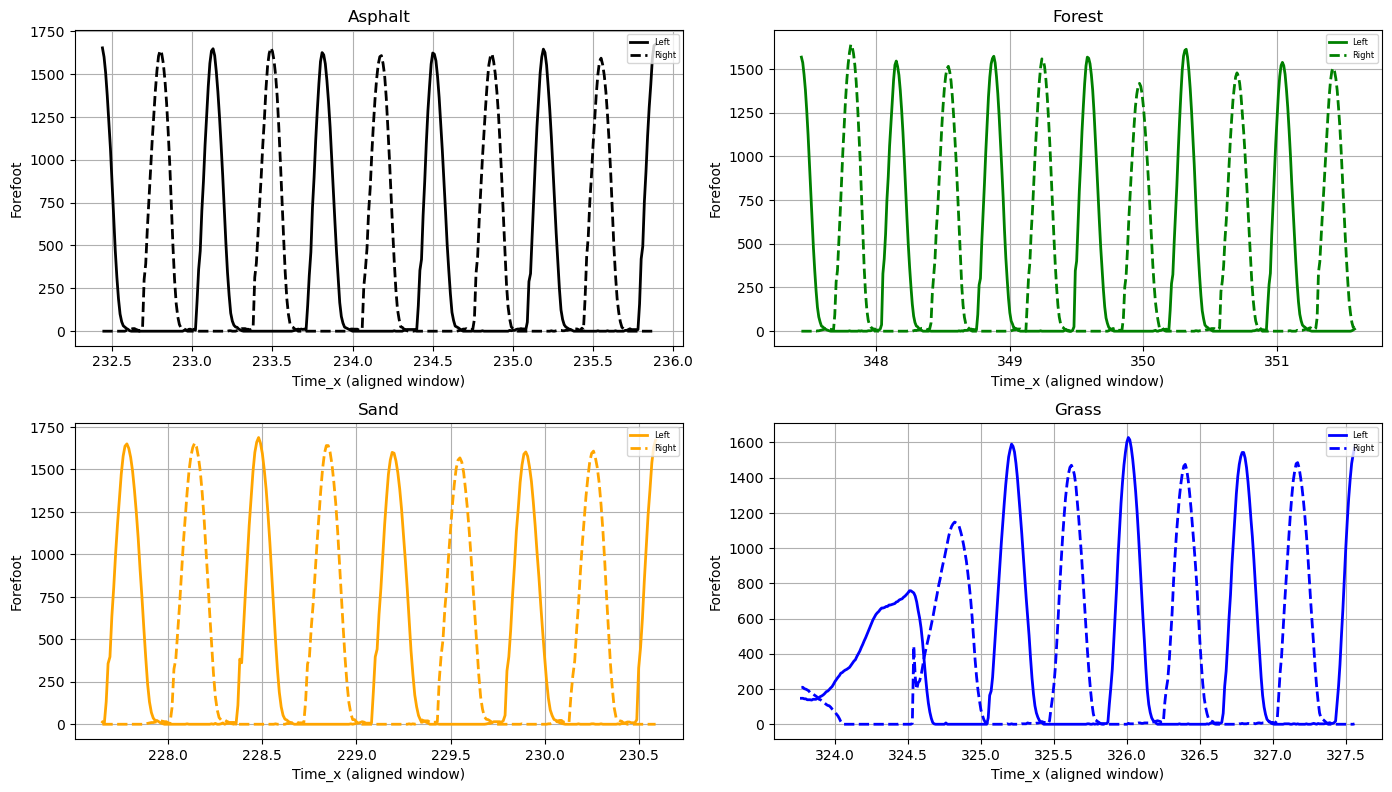

In [48]:

surfaces = {
    "Asphalt": Asphalt_S07_01_341_Date_2025_11_17_Time_10_09_36.copy(),
    "Forest":  Forest_S07_02_492_Date_2025_11_17_Time_09_53_52.copy(),
    "Sand":    Sand__S07_01_073_Date_2025_11_17_Time_09_15_09.copy(),
    "Grass":   Grass_S07_01_980_Date_2025_11_17_Time_09_27_24.copy(),
}

colors = {"Asphalt":"black", "Forest":"green", "Sand":"orange", "Grass":"blue"}
time_col = "Time_x"
min_peak_distance = 80 # sehr nahe Peaks (Artefakte, Rauschen) unterdrückt

def middle_window(df, value_col):
    peaks, _ = find_peaks(df[value_col].to_numpy(), distance=min_peak_distance)
    if len(peaks) < 4:
        raise ValueError(f"Not enough peaks in {value_col}: {len(peaks)}")
    mid = len(peaks) // 2
    p = peaks[mid-2:mid+2]  # 4 peaks around the middle
    t0, t1 = df.loc[p[0], time_col], df.loc[p[-1], time_col]
    return (float(min(t0, t1)), float(max(t0, t1)))

def slice_time(df, t0, t1):
    return df[(df[time_col] >= t0) & (df[time_col] <= t1)].sort_values(time_col)

def interp_to(df_src, t_ref, value_col):
    df_src = df_src.sort_values(time_col)
    x = df_src[time_col].to_numpy()
    y = df_src[value_col].to_numpy()
    x, idx = np.unique(x, return_index=True)  # remove duplicate times
    y = y[idx]
    return np.interp(t_ref, x, y)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, (surface, df) in zip(axes, surfaces.items()):

    df = df[[time_col, "L_Forefoot", "R_Forefoot"]].dropna().sort_values(time_col)


    t0, t1 = middle_window(df, "L_Forefoot")

    seg = slice_time(df, t0, t1)

    t_ref = seg[time_col].to_numpy()
    yL = seg["L_Forefoot"].to_numpy()
    yR = seg["R_Forefoot"].to_numpy()

    ax.plot(t_ref, yL, lw=2, color=colors[surface], label="Left")
    ax.plot(t_ref, yR, lw=2, color=colors[surface], ls="--", label="Right")

    ax.set_title(surface)
    ax.set_xlabel("Time_x (aligned window)")
    ax.set_ylabel("Forefoot")
    ax.grid(True)
    ax.legend(loc="upper right", fontsize=6)

plt.tight_layout(pad=1)
plt.savefig(
    r"C:/Users/abolhassni/Desktop/TU Darmstadt/Term 2/bewegung/Bilder/5_Schritte.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)
plt.show()


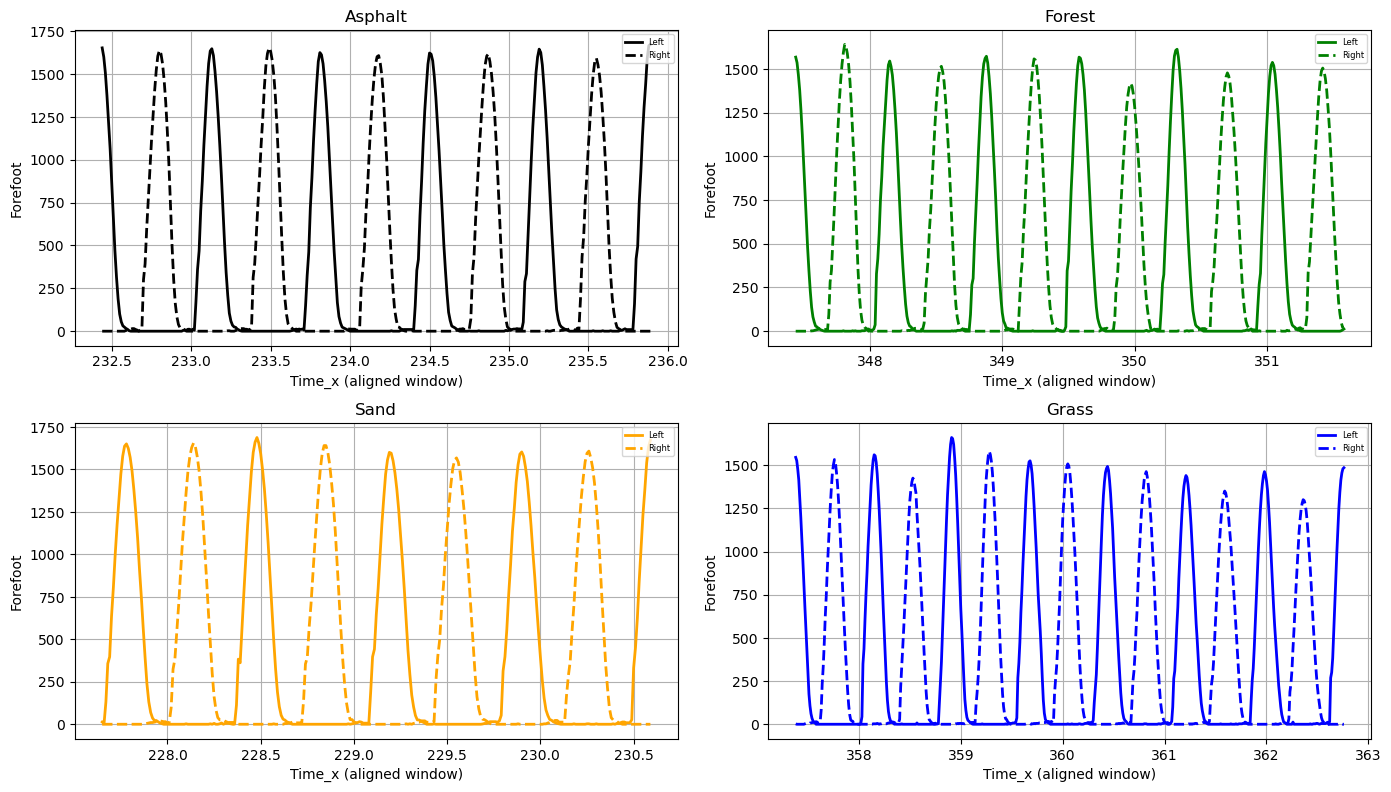

In [54]:
surfaces = {
    "Asphalt": Asphalt_S07_01_341_Date_2025_11_17_Time_10_09_36.copy(),
    "Forest":  Forest_S07_02_492_Date_2025_11_17_Time_09_53_52.copy(),
    "Sand":    Sand__S07_01_073_Date_2025_11_17_Time_09_15_09.copy(),
    "Grass":   Grass_S07_01_980_Date_2025_11_17_Time_09_27_24.copy(),
}

colors = {"Asphalt":"black", "Forest":"green", "Sand":"orange", "Grass":"blue"}
time_col = "Time_x"
min_peak_distance = 80


def middle_window(df, value_col):
    peaks, _ = find_peaks(df[value_col].to_numpy(), distance=min_peak_distance)
    if len(peaks) < 4:
        raise ValueError(f"Not enough peaks in {value_col}: {len(peaks)}")
    mid = len(peaks) // 2
    p = peaks[mid-2:mid+2]
    t0, t1 = df.loc[p[0], time_col], df.loc[p[-1], time_col]
    return float(min(t0, t1)), float(max(t0, t1))


def middle_window_grass(df, value_col, prom_ratio=0.25):
    y = df[value_col].to_numpy()
    prom = prom_ratio * np.nanmax(y)

    peaks, _ = find_peaks(y, distance=min_peak_distance, prominence=prom)

    
    if len(peaks) < 4:
        peaks, _ = find_peaks(y, distance=min_peak_distance, prominence=0.15 * np.nanmax(y))

    if len(peaks) < 4:
        raise ValueError(f"Not enough peaks in Grass after filtering: {len(peaks)}")

    mid = len(peaks) // 2
    p = peaks[mid-2:mid+2]
    t0, t1 = df.loc[p[0], time_col], df.loc[p[-1], time_col]
    return float(min(t0, t1)), float(max(t0, t1))

def slice_time(df, t0, t1):
    return df[(df[time_col] >= t0) & (df[time_col] <= t1)].sort_values(time_col)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, (surface, df) in zip(axes, surfaces.items()):
    df = df[[time_col, "L_Forefoot", "R_Forefoot"]].dropna().sort_values(time_col)

    if surface == "Grass":
        t0, t1 = middle_window_grass(df, "L_Forefoot", prom_ratio=0.25)
    else:
        t0, t1 = middle_window(df, "L_Forefoot")

    seg = slice_time(df, t0, t1)
    t_ref = seg[time_col].to_numpy()
    yL = seg["L_Forefoot"].to_numpy()
    yR = seg["R_Forefoot"].to_numpy()

    ax.plot(t_ref, yL, lw=2, color=colors[surface], label="Left")
    ax.plot(t_ref, yR, lw=2, color=colors[surface], ls="--", label="Right")

    ax.set_title(surface)
    ax.set_xlabel("Time_x (aligned window)")
    ax.set_ylabel("Forefoot")
    ax.grid(True)
    ax.legend(loc="upper right", fontsize=6)

plt.tight_layout(pad=1)
plt.savefig(
    r"C:/Users/abolhassni/Desktop/TU Darmstadt/Term 2/bewegung/Bilder/5_Schritte.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)
plt.show()


In [47]:
df_col.columns


Index(['type name', 'value', 'foundation', 'Date', 'Start_Time',
       'Time_Running', 'Time_x', 'L_Heel', 'L_Midfoot', 'L_Forefoot',
       'Total_L_Foot', 'R_Forefoot', 'R_Midfoot', 'R_Heel', 'Total_R_Foot',
       'Time_y', 'HR (bpm)', 'Speed (km/h)', 'Pace (min/km)', 'Cadence',
       'Altitude (m)', 'Stride length (m)', 'Distances (m)',
       'Temperatures (C)', 'Power (W)', 'latitude', 'longitude', 'elevation'],
      dtype='object')

Index(['L_Heel', 'L_Midfoot', 'L_Forefoot', 'Total_L_Foot', 'R_Forefoot',
       'R_Midfoot', 'R_Heel', 'Total_R_Foot'],
      dtype='object')


C:\Users\abolhassni\AppData\Local\Temp\ipykernel_9644\1102571006.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left', fontsize=5)


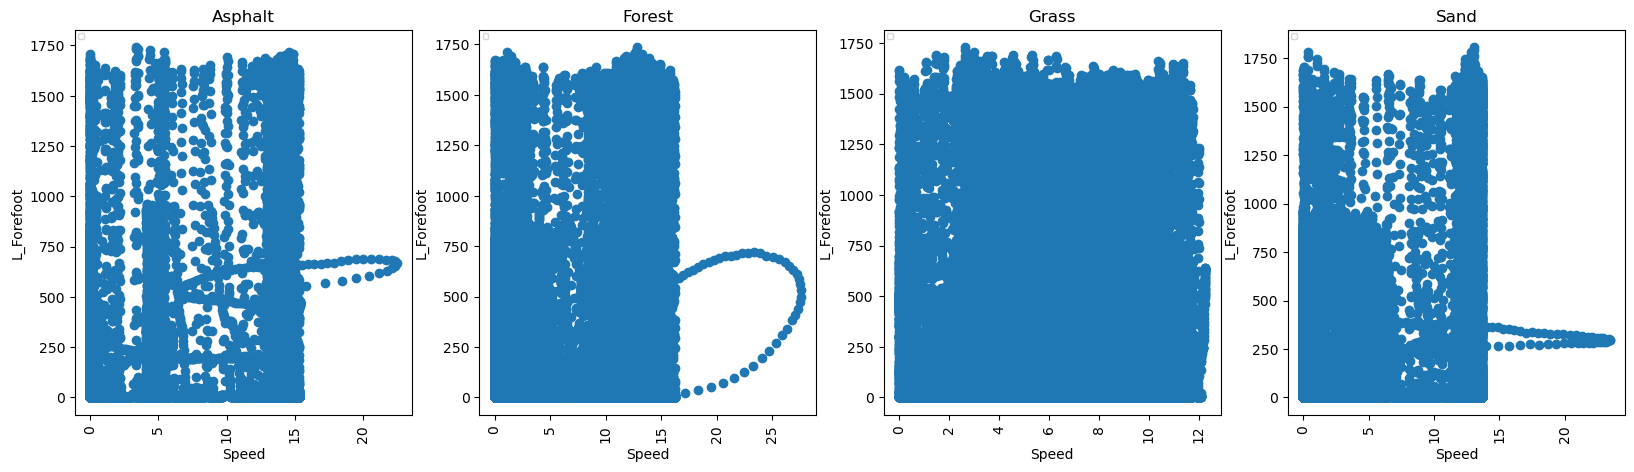

In [48]:

name_17 = [name_of_dataframe[i] for i in [0, 1, 3, 4]]
df_col = globals()[name_17[0]].copy()
col = df_col.columns[7:15].copy()

columns_to_check = ['L_Heel', 'L_Midfoot', 'L_Forefoot','Total_L_Foot',
                    'R_Forefoot', 'R_Midfoot', 'R_Heel', 'Total_R_Foot',
                    'Speed (km/h)']

loc_plot = 1
plt.figure(figsize=(20,5))
print(col)
for i in name_17:
    df = globals()[i].copy()   
    plt.subplot(1,4,loc_plot)
    plt.scatter(df["Speed (km/h)"],df["L_Forefoot"])

   
    loc_plot+=1
    plt.xlabel("Speed")
    plt.xticks(rotation=90)
    plt.ylabel("L_Forefoot")
    plt.title(f"{df["foundation"].iloc[0]}")
    plt.legend(loc='upper left', fontsize=5)

Asphalt: using columns -> impuls_L, impuls_R
Forest: using columns -> Impuls_L, Impuls_R
Grass: using columns -> impuls_L, impuls_R
Sand: using columns -> impuls_L, impuls_R


C:\Users\abolhassni\AppData\Local\Temp\ipykernel_11584\3886634464.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


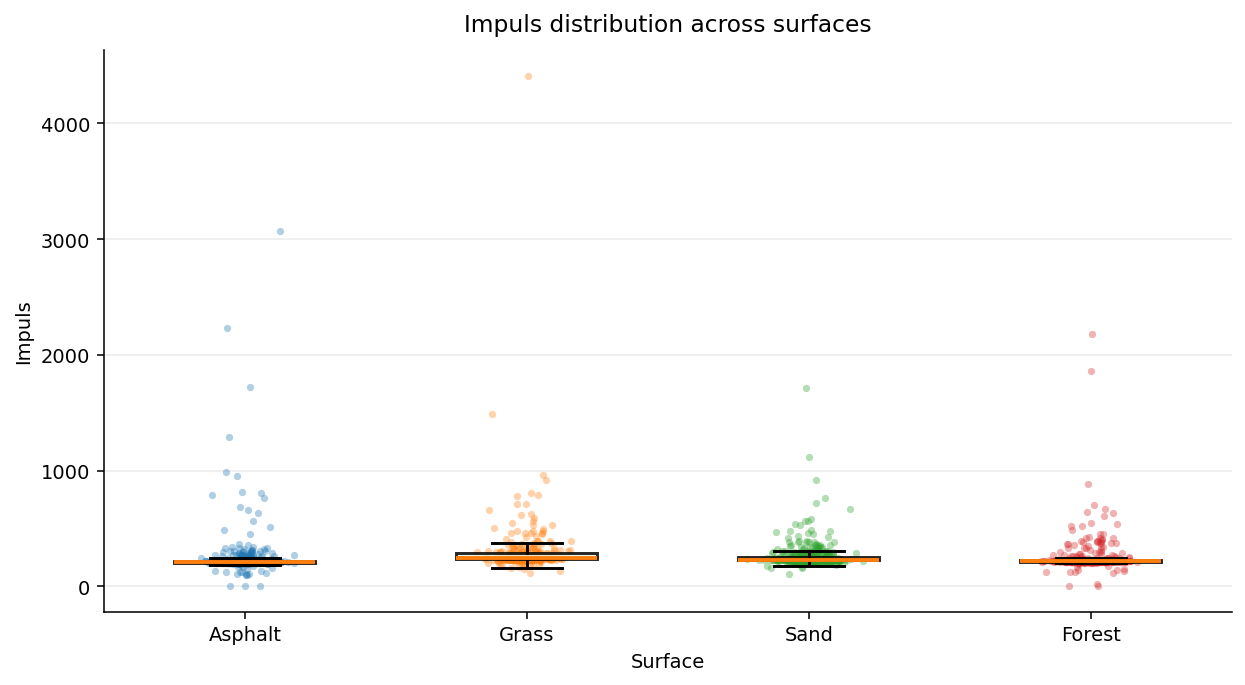

In [52]:


files = {
    "Asphalt": "C:/Users/abolhassni/Desktop/df_all_asphalt.csv",
    "Forest":  "C:/Users/abolhassni/Desktop/df_all_ّForest.csv",
    "Grass":   "C:/Users/abolhassni/Desktop/df_all_Grass.csv",
    "Sand":    "C:/Users/abolhassni/Desktop/df_all_Sand.csv",
}

def find_impuls_LR_cols(df: pd.DataFrame):
    cols = list(df.columns)
    lower = {c: c.lower() for c in cols}


    L_cols = [c for c in cols if c.endswith("_L") and ("impuls" in lower[c] or "impulse" in lower[c])]
    R_cols = [c for c in cols if c.endswith("_R") and ("impuls" in lower[c] or "impulse" in lower[c])]

    if not L_cols or not R_cols:
        raise KeyError(
            "impuls/impulse _L/_R columns not found.\n"
            f"Columns are: {cols}\n"
            "Tip: expected something like 'impuls_L' and 'impuls_R'."
        )

    return L_cols[0], R_cols[0]

dfs = []
for surface, path in files.items():
    df = pd.read_csv(path)

    col_L, col_R = find_impuls_LR_cols(df)
    print(f"{surface}: using columns -> {col_L}, {col_R}")

    tmp = pd.DataFrame({
        "Impulse": df[[col_L, col_R]].mean(axis=1),
        "Surface": surface
    })
    dfs.append(tmp)

df_all = pd.concat(dfs, ignore_index=True).dropna(subset=["Impulse"])

order = ["Asphalt", "Grass", "Sand", "Forest"]
order = [s for s in order if s in df_all["Surface"].unique()]
groups = [df_all.loc[df_all["Surface"] == s, "Impulse"].to_numpy() for s in order]

fig, ax = plt.subplots(figsize=(9, 5), dpi=140)

bp = ax.boxplot(
    groups,
    labels=order,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    boxprops=dict(linewidth=1.5),
)

facecolors = ["#DCEBFF", "#E6F7E6", "#FFF3D6", "#F0E6FF"]
for patch, fc in zip(bp["boxes"], facecolors[:len(order)]):
    patch.set_facecolor(fc)
    patch.set_alpha(0.85)

rng = np.random.default_rng(42)
for i, y in enumerate(groups, start=1):
    x = rng.normal(loc=i, scale=0.06, size=len(y))
    ax.scatter(x, y, s=14, alpha=0.35, linewidths=0)

ax.grid(True, axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.set_title("Impuls distribution across surfaces", pad=10)
ax.set_xlabel("Surface")
ax.set_ylabel("Impuls") 

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


In [50]:
print(df[[col_L, col_R]].describe())


          impuls_L     impuls_R
count   438.000000   438.000000
mean    260.263856   260.780263
std     188.585644    98.834738
min       0.517400     0.524900
25%     217.245025   227.616650
50%     225.576250   236.221800
75%     245.564400   254.928875
max    3107.457700  1234.105100
